# Import Libraries

In [1]:
# 📦 Core Libraries
import numpy as np
import pandas as pd
import math
import warnings

# 📊 Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# 🔕 Suppress Warnings
warnings.filterwarnings("ignore")

# ⚙️ Machine Learning Models
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# 🧩 Feature Engineering & Preprocessing
from category_encoders import TargetEncoder
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 🧪 Model Evaluation
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# 🔍 Model Explainability
import shap

# Load Data

In [2]:
# 📥 Load the dataset
df = pd.read_csv("/kaggle/input/heat-disease-predication-dataset/synthetic_heart_disease_dataset.csv")

# 🧾 Display dataset shape
print("Dataset shape:", df.shape)

# 👁️ Preview the data
df.head()

Dataset shape: (50000, 21)


,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


# Initial Data Inspection

In [3]:
df.shape

(50000, 21)

In [4]:
# 📋 Check column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [5]:
# ✅ Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: ['Age', 'Weight', 'Height', 'BMI', 'Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total', 'Heart_Disease']
Categorical Columns: ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity', 'Diet', 'Stress_Level']


In [6]:
# 🔍 Check for missing values
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0]
missing_df

,Missing Values,Percentage
Alcohol_Intake,20109,40.218


In [7]:
# 📊 Descriptive statistics for numerical columns
df[numerical_cols].describe()

,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [8]:
# 🔢 Unique value counts for categorical columns
for col in categorical_cols:
    print(f"\nUnique values in '{col}':")
    print(df[col].value_counts())


Unique values in 'Gender':
Gender
Female    25110
Male      24890
Name: count, dtype: int64

Unique values in 'Smoking':
Smoking
Never      30160
Current     9965
Former      9875
Name: count, dtype: int64

Unique values in 'Alcohol_Intake':
Alcohol_Intake
Low         14913
Moderate     9895
High         5083
Name: count, dtype: int64

Unique values in 'Physical_Activity':
Physical_Activity
Moderate     24976
Sedentary    15077
Active        9947
Name: count, dtype: int64

Unique values in 'Diet':
Diet
Average      25169
Healthy      14975
Unhealthy     9856
Name: count, dtype: int64

Unique values in 'Stress_Level':
Stress_Level
Medium    20133
Low       19941
High       9926
Name: count, dtype: int64


# Exploratory Data Analysis (EDA)

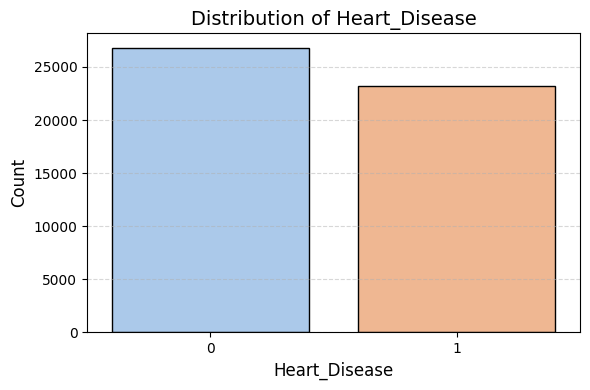


📊 Heart_Disease Counts (Proportions):
Heart_Disease
0    0.537
1    0.463
Name: proportion, dtype: float64


In [9]:
target = 'Heart_Disease'
cat_col = categorical_cols
num_col = numerical_cols

# 🎯 Target Variable Distribution
# We begin by analyzing the distribution of our target variable, Personality, to see if the dataset is balanced between Extrovert and Introvert.

# === USER SETTINGS ===
target_col = target  # specify your target column here

# === TARGET VARIABLE DISTRIBUTION ===
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x=target_col, palette='pastel', edgecolor='black')
plt.title(f'Distribution of {target_col}', fontsize=14)
plt.xlabel(target_col, fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Display normalized value counts (as proportions)
print(f"\n📊 {target_col} Counts (Proportions):")
print(df[target_col].value_counts(normalize=True).round(3))

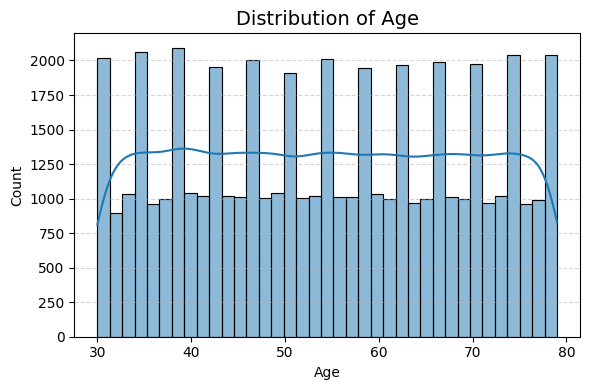


📊 Descriptive Stats for Age:

count    50000.00000
mean        54.46406
std         14.43809
min         30.00000
25%         42.00000
50%         54.00000
75%         67.00000
max         79.00000
Name: Age, dtype: float64 
----------------------------------------


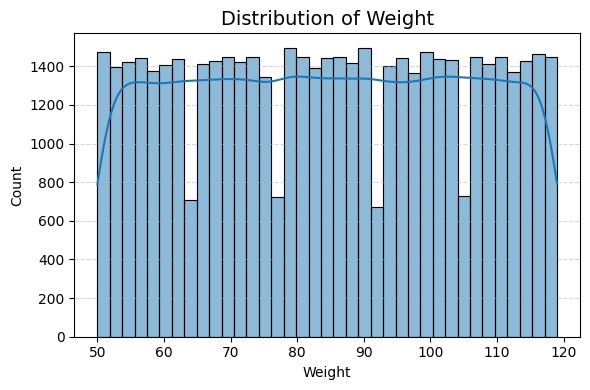


📊 Descriptive Stats for Weight:

count    50000.000000
mean        84.547520
std         20.213257
min         50.000000
25%         67.000000
50%         85.000000
75%        102.000000
max        119.000000
Name: Weight, dtype: float64 
----------------------------------------


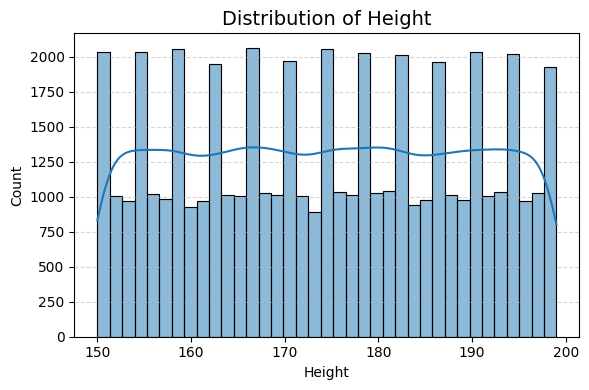


📊 Descriptive Stats for Height:

count    50000.000000
mean       174.460000
std         14.420379
min        150.000000
25%        162.000000
50%        174.000000
75%        187.000000
max        199.000000
Name: Height, dtype: float64 
----------------------------------------


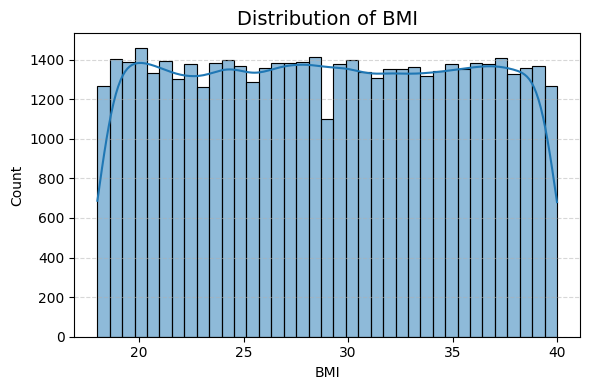


📊 Descriptive Stats for BMI:

count    50000.000000
mean        28.984284
std          6.367494
min         18.000000
25%         23.500000
50%         29.000000
75%         34.500000
max         40.000000
Name: BMI, dtype: float64 
----------------------------------------


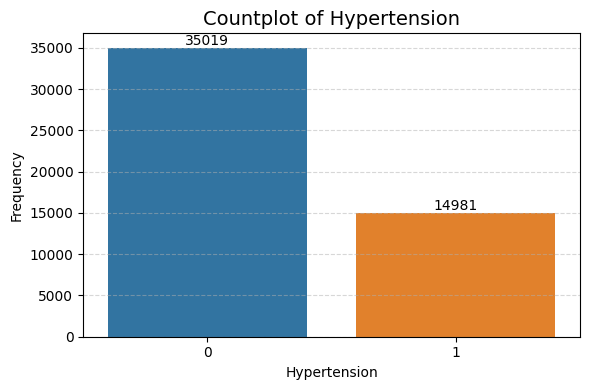


📊 Descriptive Stats for Hypertension:

count    50000.000000
mean         0.299620
std          0.458096
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Hypertension, dtype: float64 
----------------------------------------


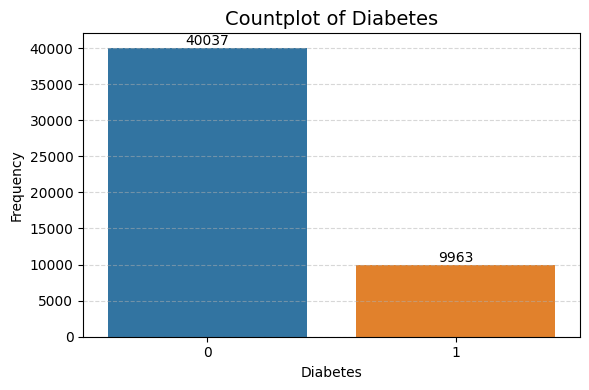


📊 Descriptive Stats for Diabetes:

count    50000.000000
mean         0.199260
std          0.399448
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Diabetes, dtype: float64 
----------------------------------------


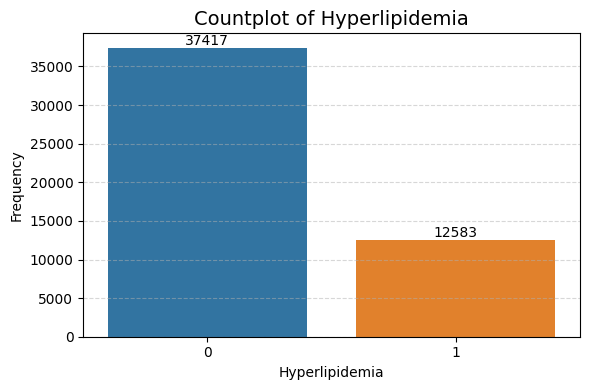


📊 Descriptive Stats for Hyperlipidemia:

count    50000.000000
mean         0.251660
std          0.433971
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Hyperlipidemia, dtype: float64 
----------------------------------------


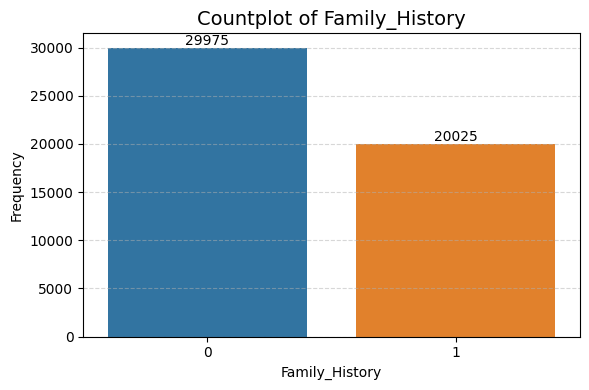


📊 Descriptive Stats for Family_History:

count    50000.000000
mean         0.400500
std          0.490005
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Family_History, dtype: float64 
----------------------------------------


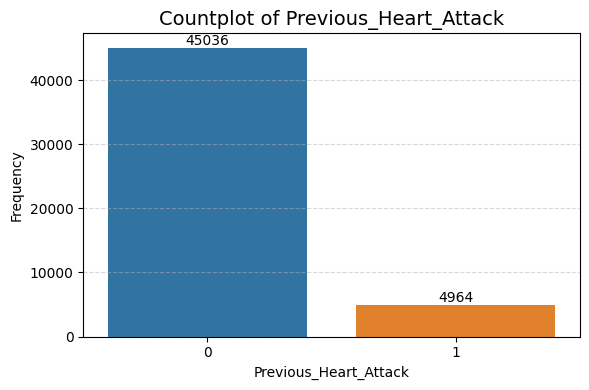


📊 Descriptive Stats for Previous_Heart_Attack:

count    50000.000000
mean         0.099280
std          0.299041
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: Previous_Heart_Attack, dtype: float64 
----------------------------------------


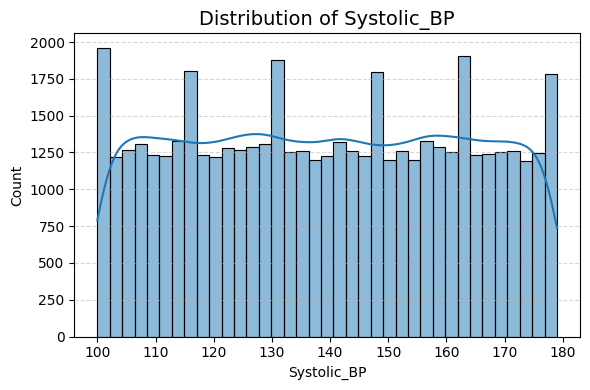


📊 Descriptive Stats for Systolic_BP:

count    50000.000000
mean       139.299580
std         23.083544
min        100.000000
25%        119.000000
50%        139.000000
75%        159.000000
max        179.000000
Name: Systolic_BP, dtype: float64 
----------------------------------------


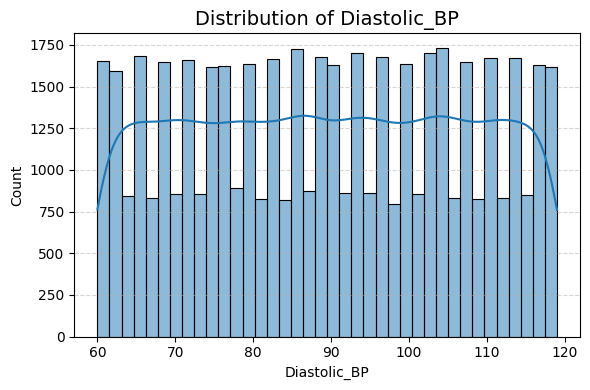


📊 Descriptive Stats for Diastolic_BP:

count    50000.000000
mean        89.528800
std         17.258063
min         60.000000
25%         75.000000
50%         90.000000
75%        104.000000
max        119.000000
Name: Diastolic_BP, dtype: float64 
----------------------------------------


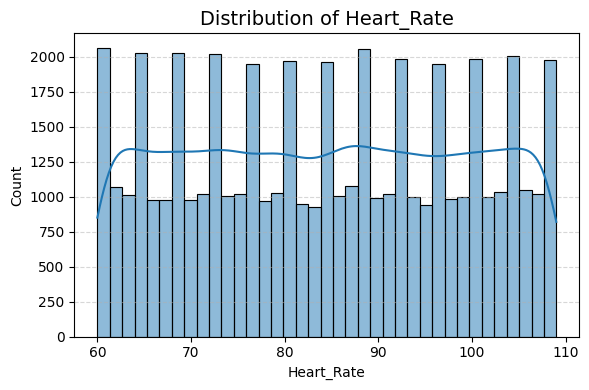


📊 Descriptive Stats for Heart_Rate:

count    50000.000000
mean        84.449560
std         14.491325
min         60.000000
25%         72.000000
50%         85.000000
75%         97.000000
max        109.000000
Name: Heart_Rate, dtype: float64 
----------------------------------------


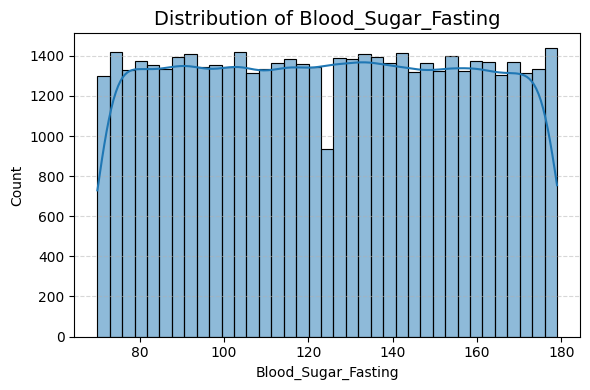


📊 Descriptive Stats for Blood_Sugar_Fasting:

count    50000.000000
mean       124.493020
std         31.691507
min         70.000000
25%         97.000000
50%        125.000000
75%        152.000000
max        179.000000
Name: Blood_Sugar_Fasting, dtype: float64 
----------------------------------------


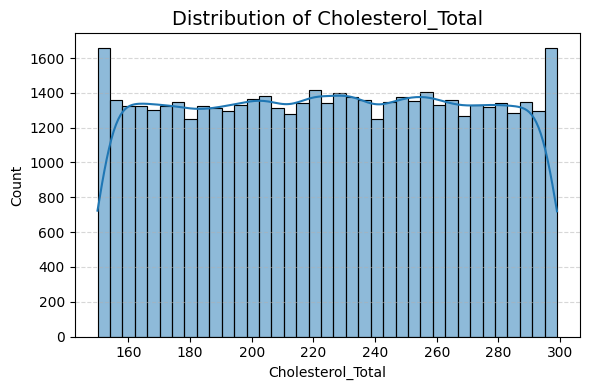


📊 Descriptive Stats for Cholesterol_Total:

count    50000.000000
mean       224.556360
std         43.157467
min        150.000000
25%        187.000000
50%        225.000000
75%        262.000000
max        299.000000
Name: Cholesterol_Total, dtype: float64 
----------------------------------------


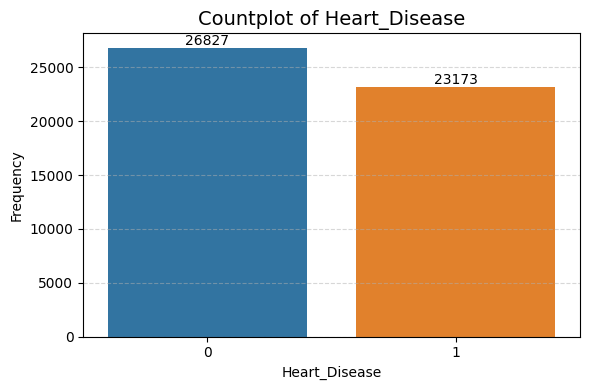


📊 Descriptive Stats for Heart_Disease:

count    50000.000000
mean         0.463460
std          0.498668
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Heart_Disease, dtype: float64 
----------------------------------------


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = num_col

for col in num_cols:
    plt.figure(figsize=(6, 4))

    # Check if column is continuous: many unique values
    if df[col].nunique() > 10:
        # Continuous numerical variable → Histogram
        sns.histplot(df[col], kde=True, edgecolor='black')
        plt.title(f'Distribution of {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel("Count")

    else:
        # Discrete numeric / categorical numeric → Countplot
        sns.countplot(x=df[col])
        plt.title(f'Countplot of {col}', fontsize=14)
        plt.xlabel(col)
        plt.ylabel("Frequency")

        # Optional: show category values on top
        for p in plt.gca().patches:
            plt.gca().annotate(
                f'{int(p.get_height())}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom'
            )

    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    # Print descriptive statistics
    print(f'\n📊 Descriptive Stats for {col}:\n')
    print(df[col].describe(), '\n' + '-'*40)

Continuous numeric columns: ['Age', 'Weight', 'Height', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting', 'Cholesterol_Total']
Categorical numeric columns: ['Hypertension', 'Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack', 'Heart_Disease']


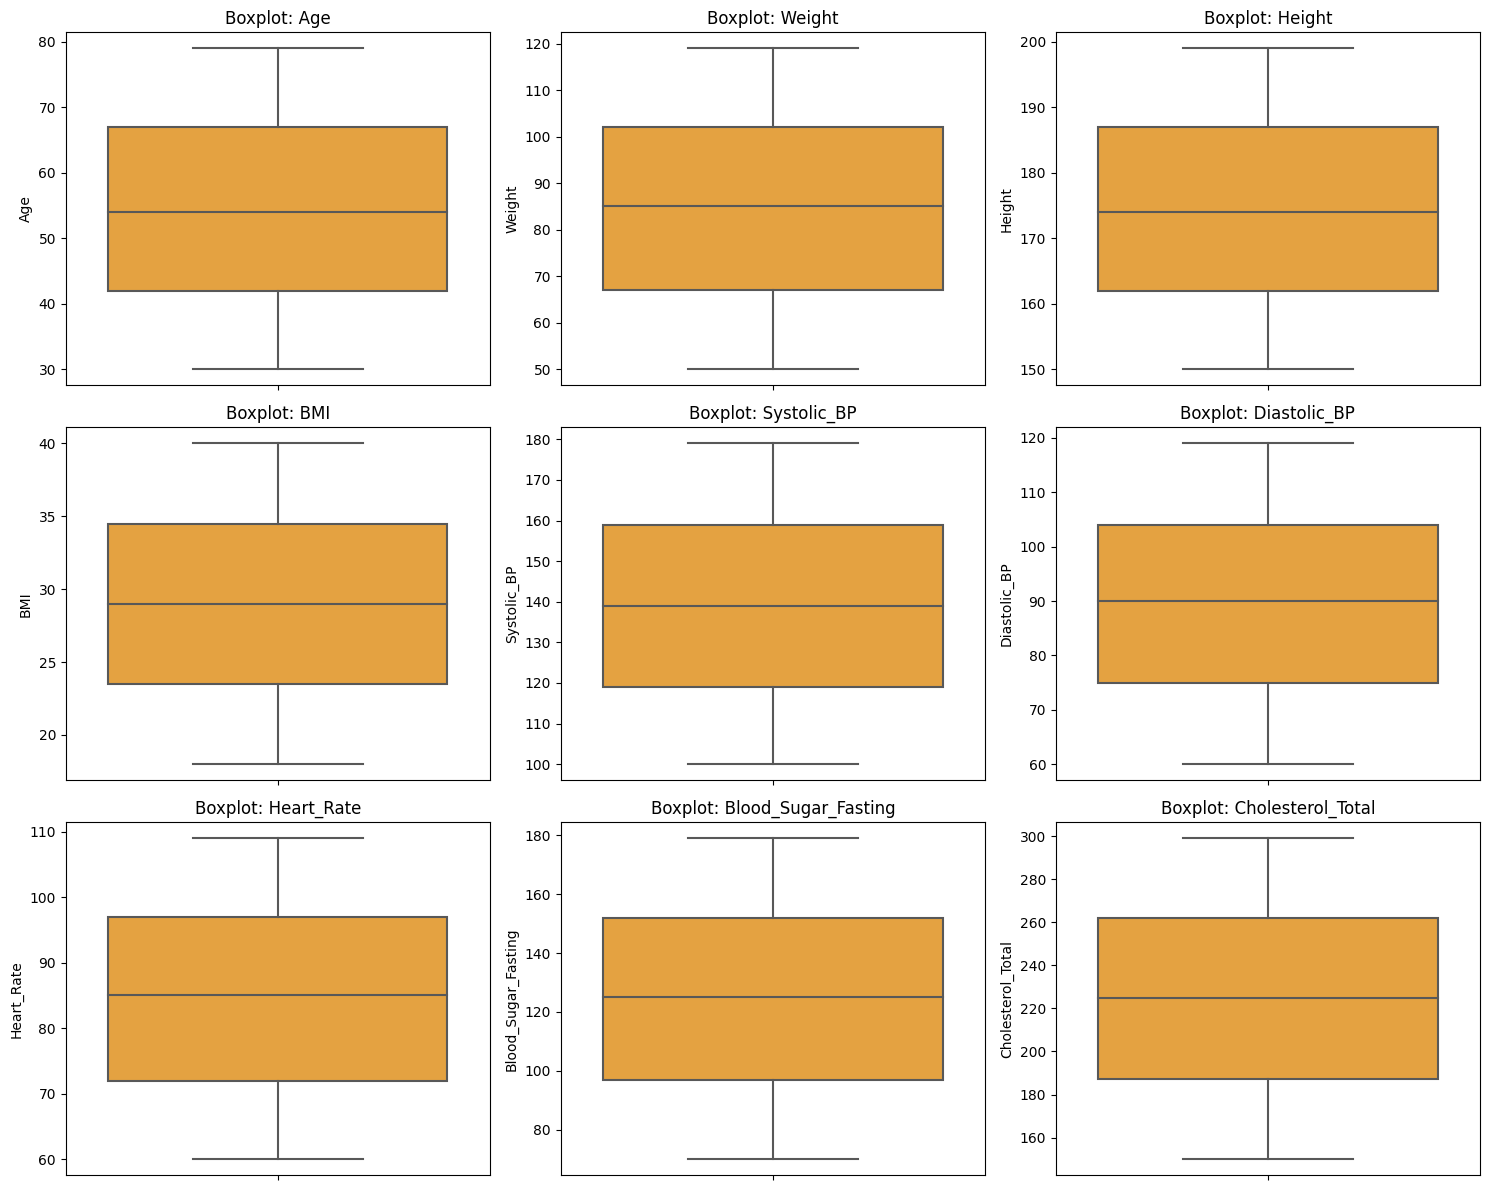

In [11]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = num_col

# === OUTLIER DETECTION: ONLY FOR CONTINUOUS VARIABLES ===
continuous_cols = [col for col in num_cols if df[col].nunique() > 10]
categorical_numeric_cols = [col for col in num_cols if df[col].nunique() <= 10]

print("Continuous numeric columns:", continuous_cols)
print("Categorical numeric columns:", categorical_numeric_cols)

# === BOXPLOTS ONLY FOR CONTINUOUS NUMERIC FEATURES ===
n = len(continuous_cols)
cols = 3
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 5, rows * 4))

for i, col in enumerate(continuous_cols):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(y=df[col], color='#FFA726')
    plt.title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

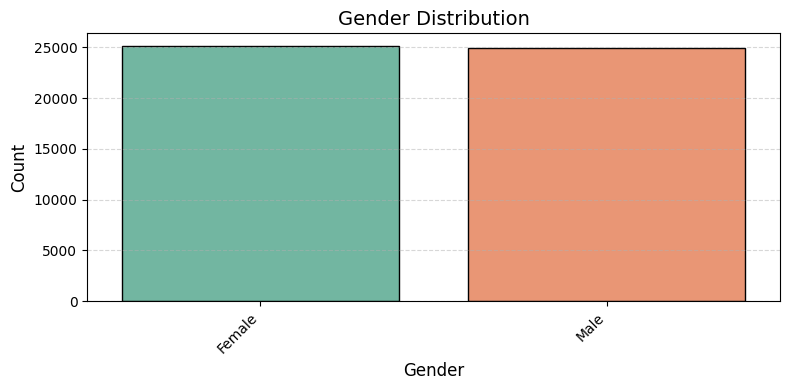


📊 Proportion of Each Category in "Gender":

Gender
Female    0.502
Male      0.498
Name: proportion, dtype: float64 
----------------------------------------


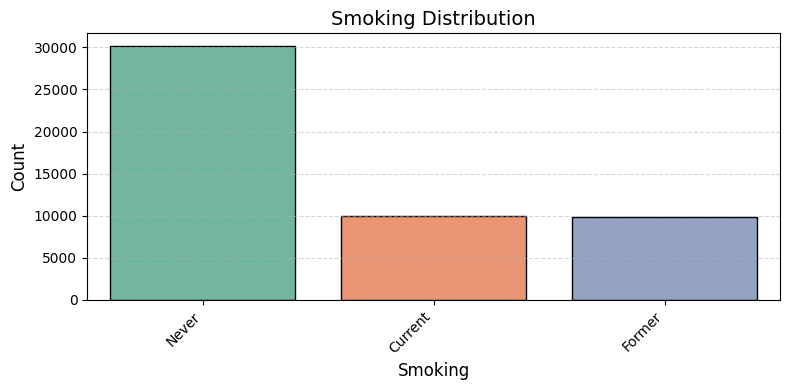


📊 Proportion of Each Category in "Smoking":

Smoking
Never      0.603
Current    0.199
Former     0.198
Name: proportion, dtype: float64 
----------------------------------------


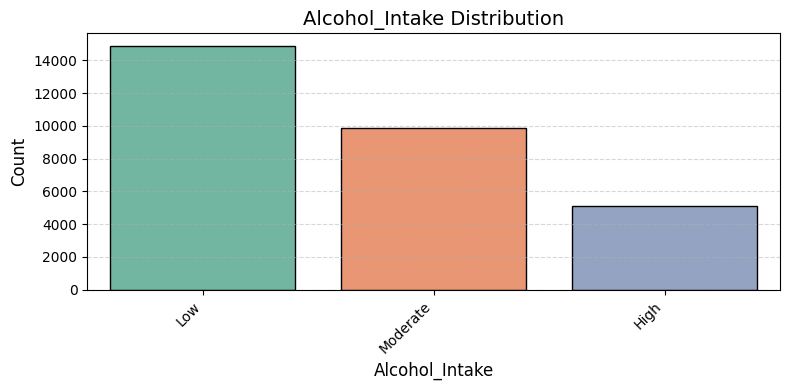


📊 Proportion of Each Category in "Alcohol_Intake":

Alcohol_Intake
Low         0.499
Moderate    0.331
High        0.170
Name: proportion, dtype: float64 
----------------------------------------


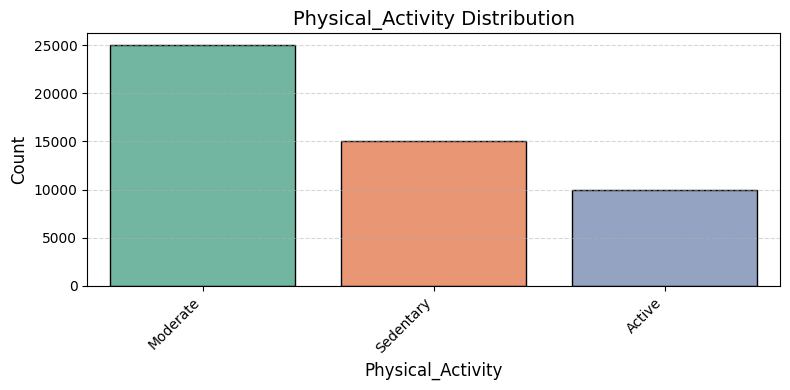


📊 Proportion of Each Category in "Physical_Activity":

Physical_Activity
Moderate     0.500
Sedentary    0.302
Active       0.199
Name: proportion, dtype: float64 
----------------------------------------


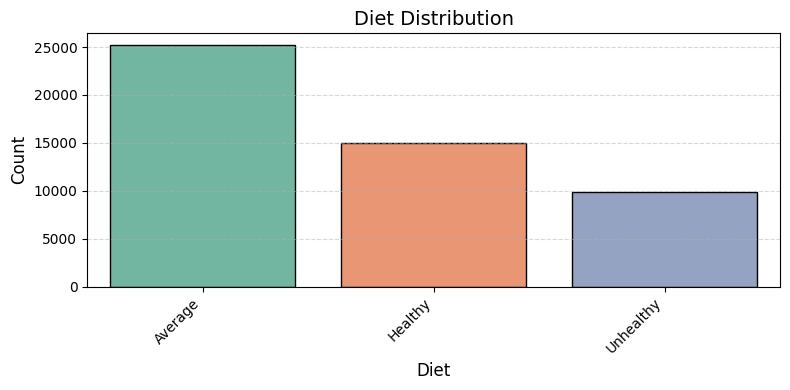


📊 Proportion of Each Category in "Diet":

Diet
Average      0.503
Healthy      0.300
Unhealthy    0.197
Name: proportion, dtype: float64 
----------------------------------------


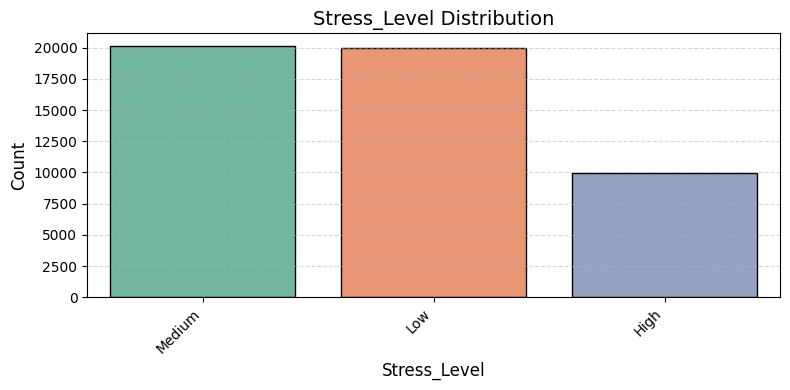


📊 Proportion of Each Category in "Stress_Level":

Stress_Level
Medium    0.403
Low       0.399
High      0.199
Name: proportion, dtype: float64 
----------------------------------------


In [12]:
# 📊 Distribution of Categorical Features
# We use countplots to examine the balance of categorical features: Stage_fear and Drained_after_socializing.

# ===== Visualize Distribution of Categorical Features =====

cat_cols = cat_col

for col in cat_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index,
        palette='Set2',
        edgecolor='black'
    )
    plt.title(f'{col} Distribution', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

    print(f'\n📊 Proportion of Each Category in "{col}":\n')
    print(df[col].value_counts(normalize=True).round(3), '\n' + '-'*40)

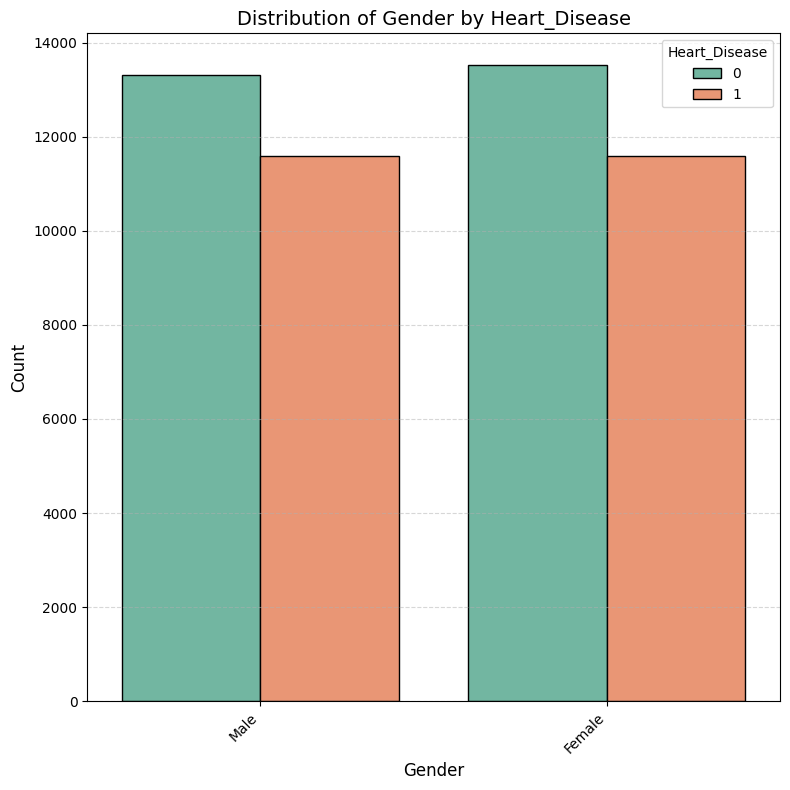

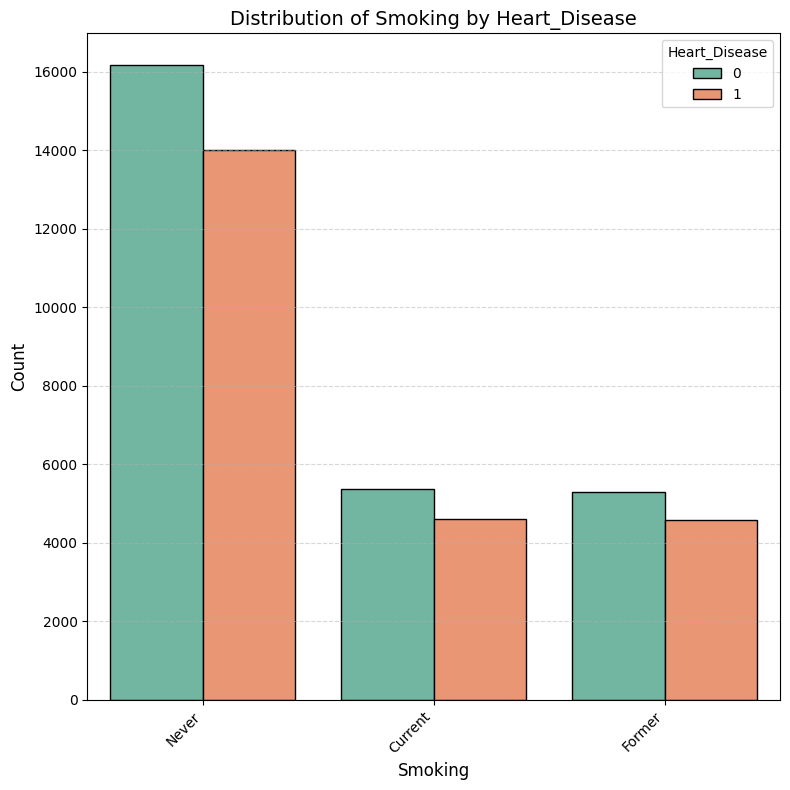

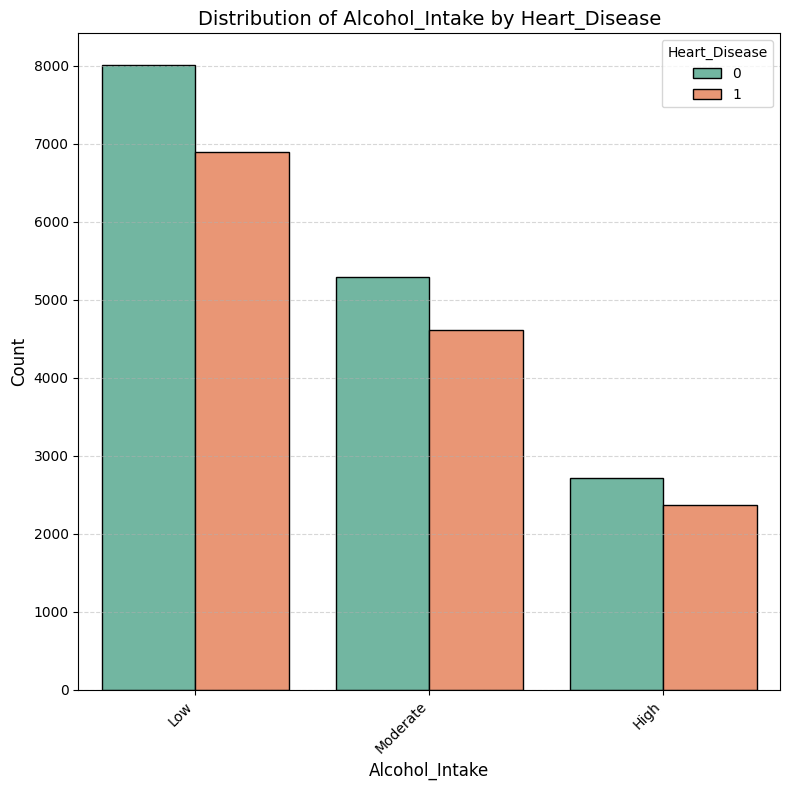

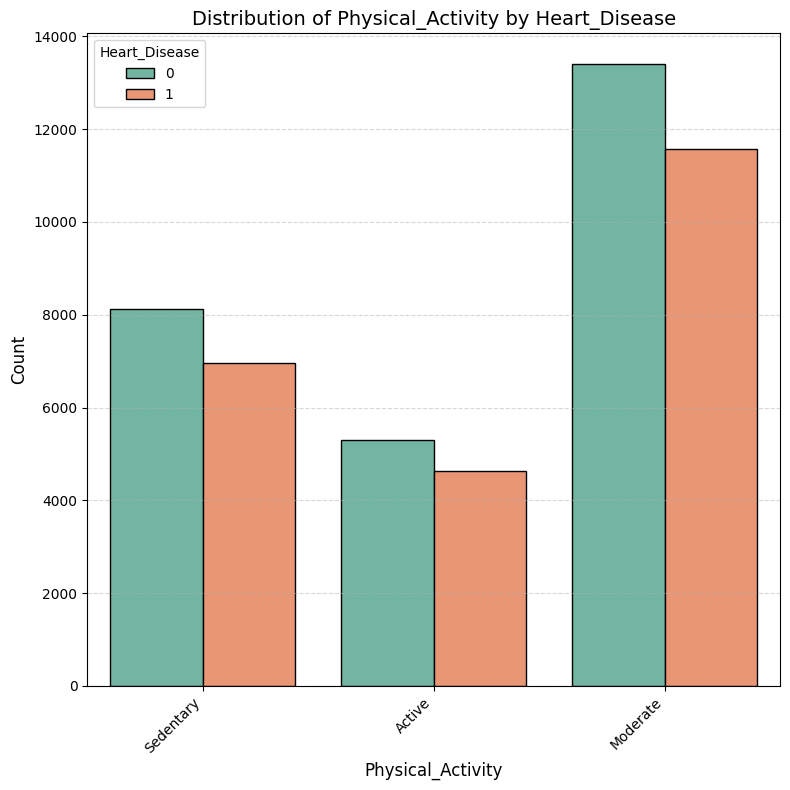

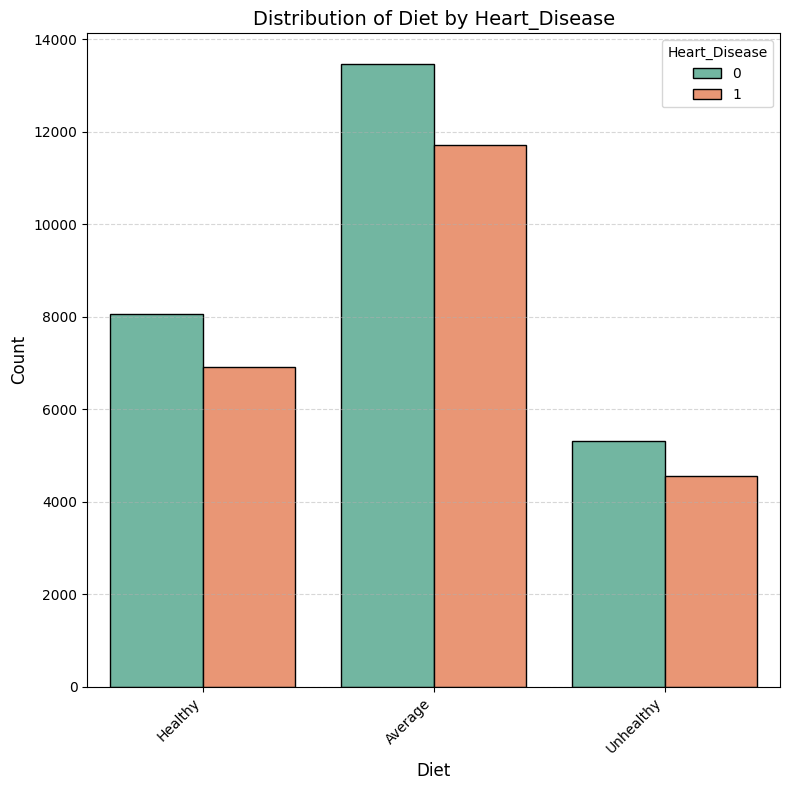

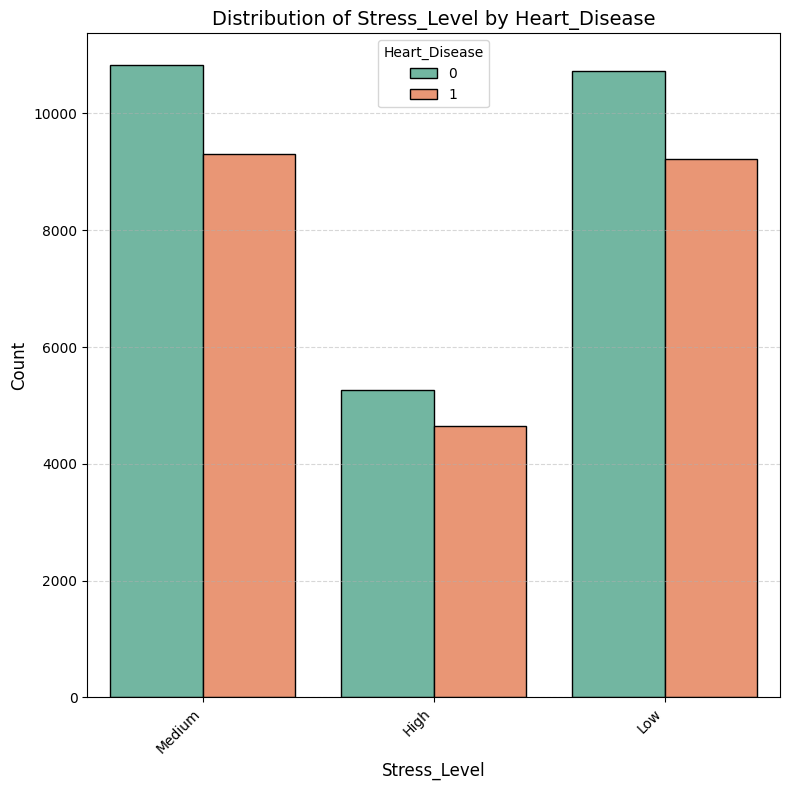

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# === USER SETTINGS ===
categorical_features = categorical_cols   # list of your categorical columns
target_col = target         # your target variable column

# === CATEGORICAL FEATURE DISTRIBUTIONS BY TARGET ===
for col in categorical_features:
    plt.figure(figsize=(8, 8))
    sns.countplot(data=df, x=col, hue=target_col, palette='Set2', edgecolor='black')
    plt.title(f'Distribution of {col} by {target_col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

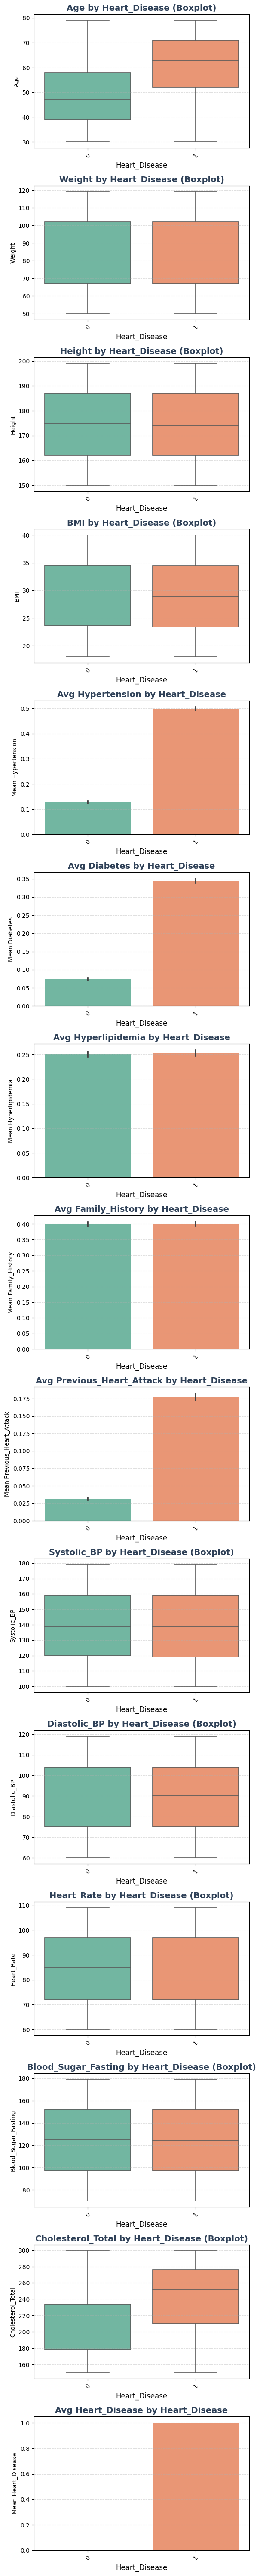

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np  # for estimator=np.mean

# num_cols = [...]
# target_col = '...'

n = len(num_cols)
cols = 1  # one plot per row
rows = math.ceil(n / cols)

plt.figure(figsize=(cols * 6, rows * 4))

for i, col in enumerate(num_cols):
    plt.subplot(rows, cols, i + 1)

    unique_vals = df[col].nunique()

    if unique_vals > 10:
        # 🔵 Continuous numeric → boxplot vs target
        sns.boxplot(
            data=df,
            x=target_col,
            y=col,
            palette='Set2',
            linewidth=1.2,
            fliersize=4
        )
        plt.title(f'{col} by {target_col} (Boxplot)', fontsize=14, fontweight='semibold', color='#2E4057')
        plt.ylabel(col)

    else:
        # 🟢 Discrete numeric → barplot of mean by target (good for 0/1 / small codes)
        sns.barplot(
            data=df,
            x=target_col,
            y=col,
            estimator=np.mean,
            errorbar='ci',   # seaborn >= 0.12; for older: ci=95
            palette='Set2'
        )
        plt.title(f'Avg {col} by {target_col}', fontsize=14, fontweight='semibold', color='#2E4057')
        plt.ylabel(f'Mean {col}')

    plt.xlabel(target_col, fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

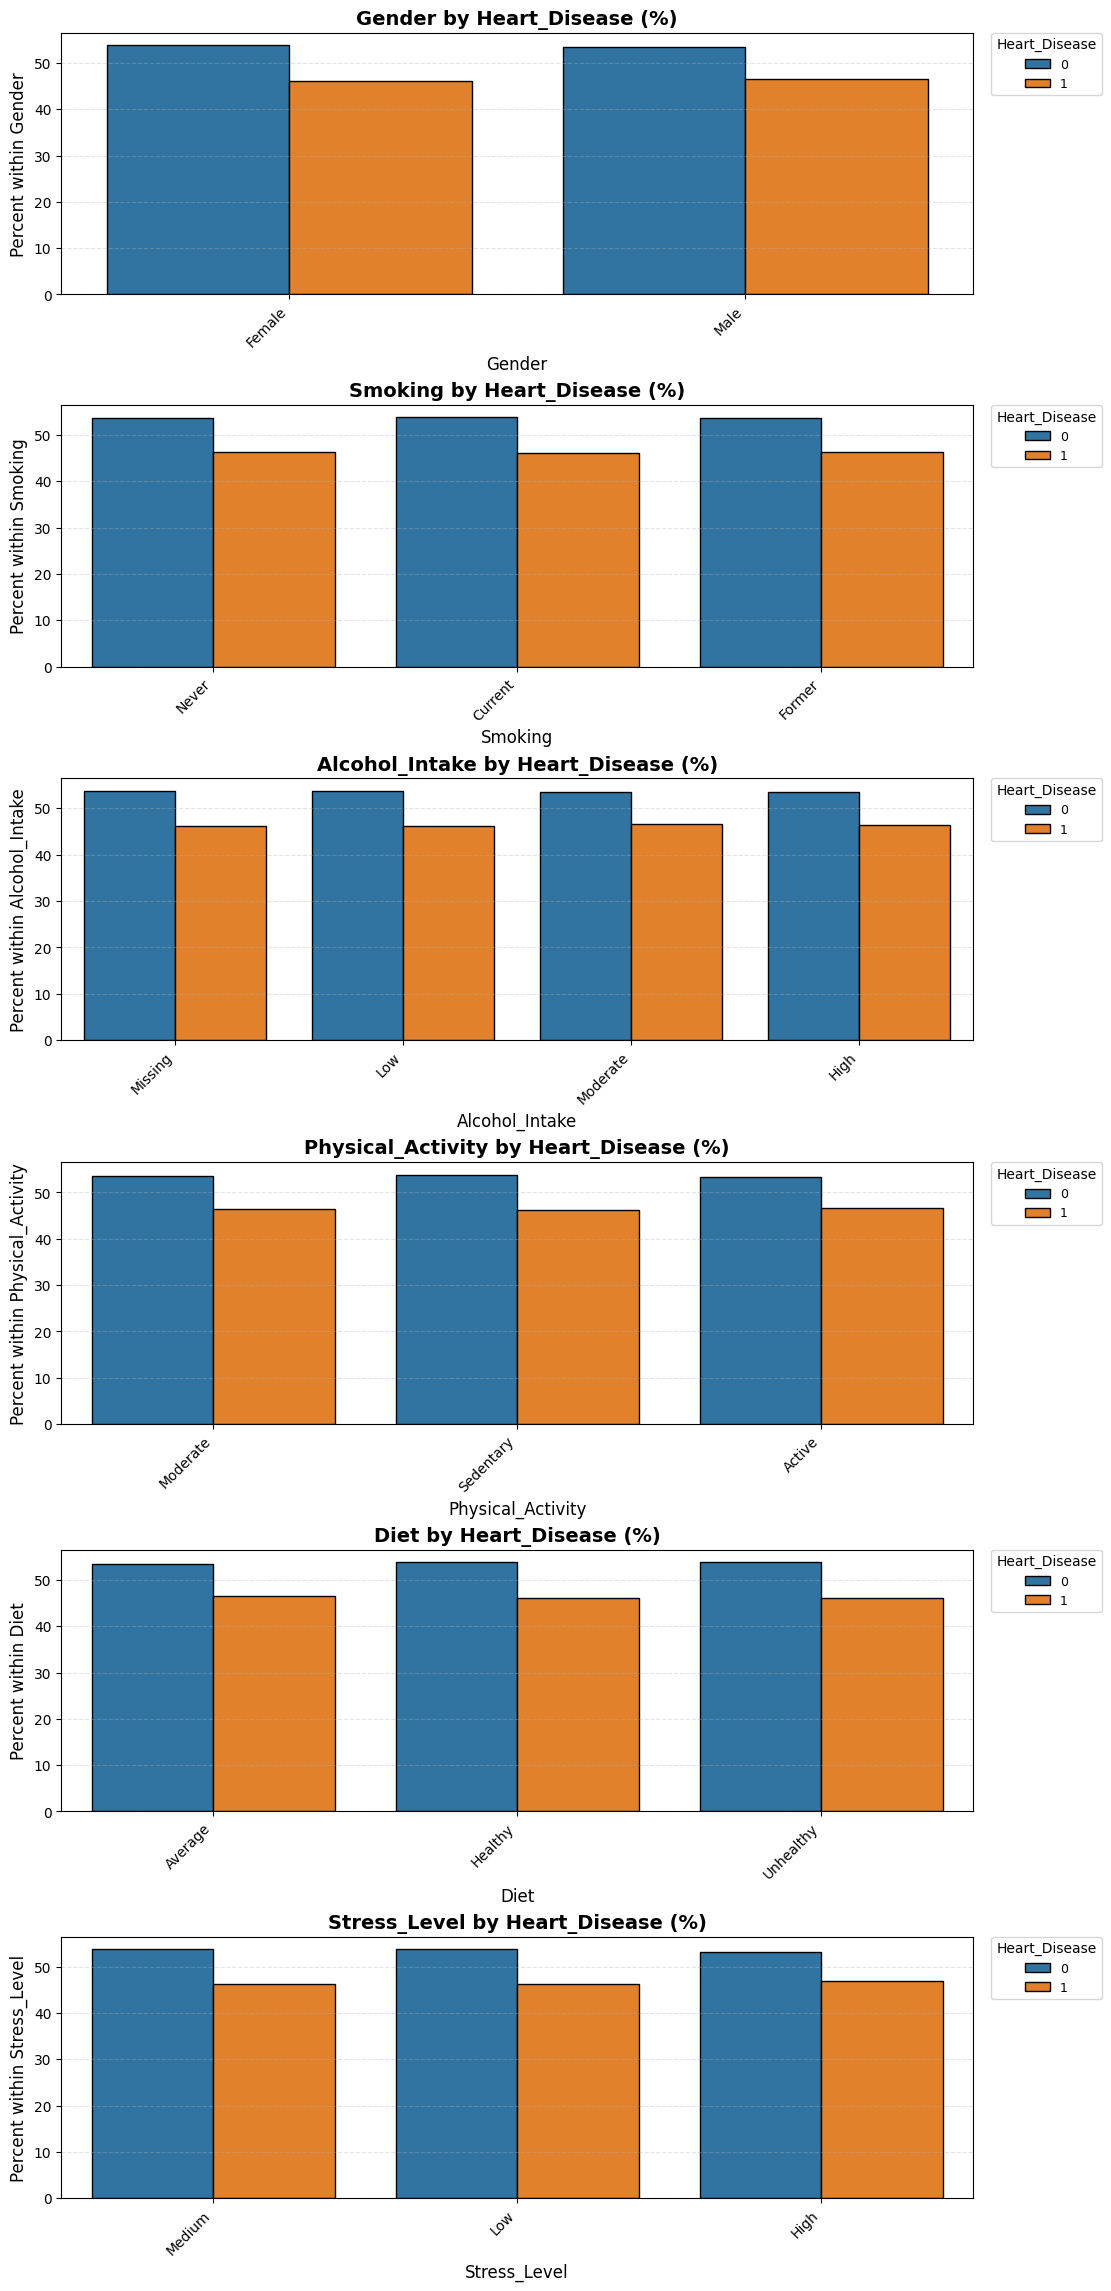

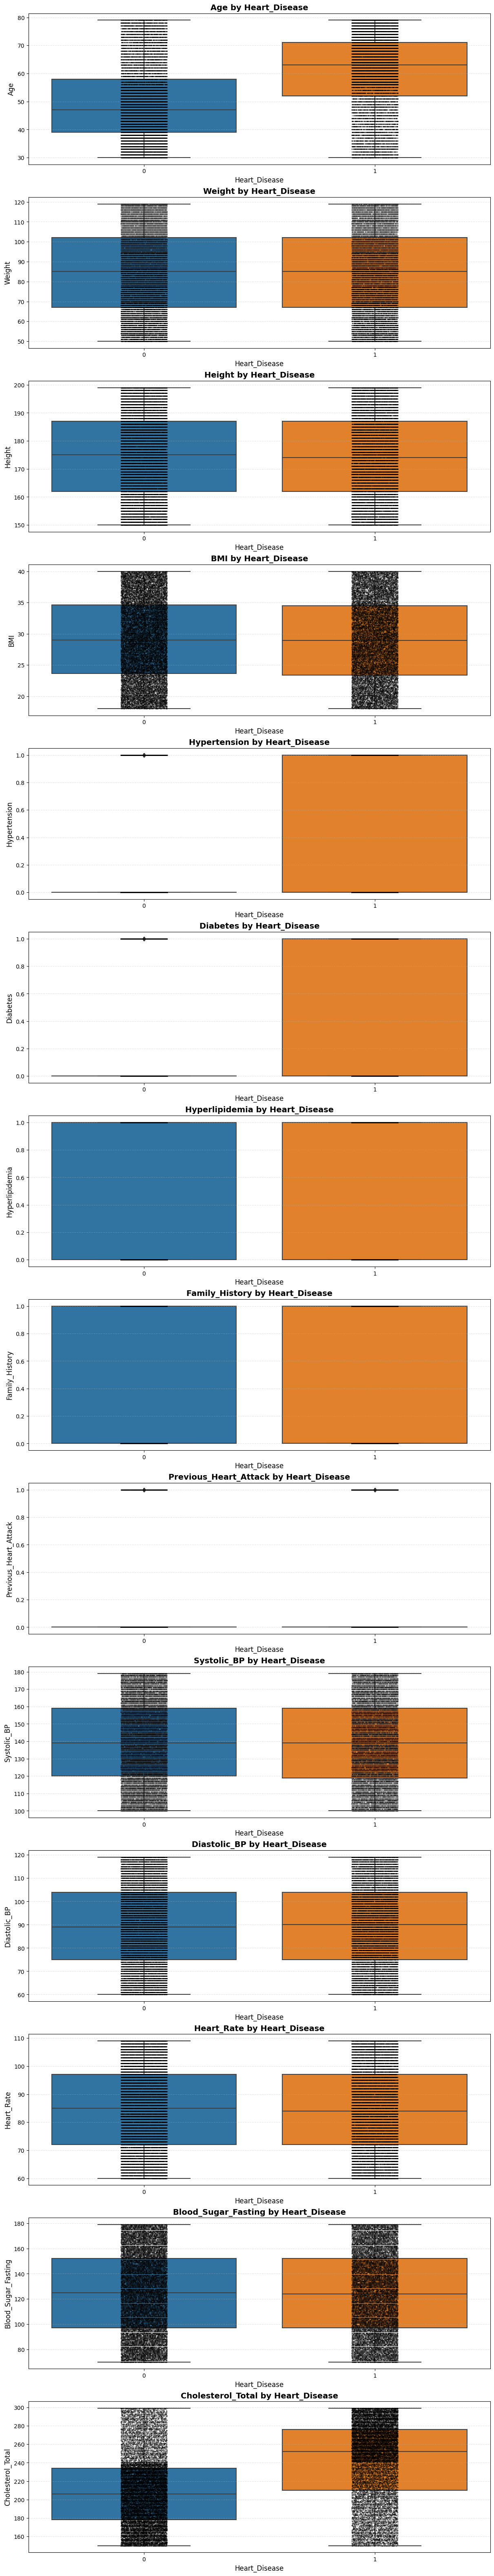

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_by_target(
    df: pd.DataFrame,
    target_col: str,
    cat_cols=None,
    num_cols=None,
    target_order=None,         # e.g., ['Poor','Fair','Neutral','Good','Excellent']
    top_n_cats: int = 20,      # limit bars for high-cardinality categorical features
    dropna_label: str = "Missing",
    show_points: bool = False  # overlay jitter on boxplots
):
    # -------------------------
    # Basic validations
    # -------------------------
    if not isinstance(target_col, str):
        raise TypeError("target_col must be a *column name string*, e.g., 'quality_label'")
    if target_col not in df.columns:
        raise ValueError(f"target_col '{target_col}' not found in df")

    # Infer cat/num columns if not provided
    if cat_cols is None:
        cat_cols = [c for c in df.columns
                    if (df[c].dtype == 'object' or str(df[c].dtype) == 'category' or df[c].dtype == 'bool')
                    and c != target_col]
    else:
        # Ensure cat_cols are strings and exist
        for c in cat_cols:
            if not isinstance(c, str):
                raise TypeError("Each entry in cat_cols must be a *column name string*")
            if c not in df.columns:
                raise ValueError(f"cat_cols contains '{c}' which is not in df")

    if num_cols is None:
        num_cols = [c for c in df.columns
                    if pd.api.types.is_numeric_dtype(df[c]) and c != target_col]
    else:
        for c in num_cols:
            if not isinstance(c, str):
                raise TypeError("Each entry in num_cols must be a *column name string*")
            if c not in df.columns:
                raise ValueError(f"num_cols contains '{c}' which is not in df")

    # Target ordering (useful for ordinal categories)
    if target_order is not None:
        # Only apply if all present target levels are in target_order
        present = pd.Series(df[target_col].dropna().unique())
        if set(present).issubset(set(target_order)):
            df = df.copy()
            df[target_col] = pd.Categorical(df[target_col], categories=target_order, ordered=True)
        else:
            print("Note: Not all target levels are in target_order; skipping explicit ordering.")
    else:
        # Warn if numeric & looks continuous
        tser = df[target_col]
        if pd.api.types.is_numeric_dtype(tser) and tser.nunique() > 10:
            print(f"Warning: target_col='{target_col}' looks continuous; grouped plots may be misleading.")

    # -------------------------
    # Plot categorical columns
    # -------------------------
    if len(cat_cols) > 0:
        fig, axes = plt.subplots(len(cat_cols), 1, figsize=(11, max(4, 3.8 * len(cat_cols))), constrained_layout=True)
        if len(cat_cols) == 1:
            axes = [axes]

        for ax, col in zip(axes, cat_cols):
            # Limit to top N categories by frequency (after filling NaNs)
            s = df[col].astype('object').fillna(dropna_label)
            top_levels = s.value_counts(dropna=False).head(top_n_cats).index
            mask = s.isin(top_levels)
            # Prepare a reduced copy for plotting
            sub = df.loc[mask, [col, target_col]].copy()
            sub[col] = sub[col].astype('object').fillna(dropna_label)
            sub[target_col] = sub[target_col].astype('object').fillna(dropna_label)

            # Normalized crosstab (% within each category of 'col')
            ct = pd.crosstab(sub[col], sub[target_col], normalize='index', dropna=False) * 100.0
            ct = ct.reset_index().melt(id_vars=col, var_name=target_col, value_name='Percent')

            # Order x by frequency (same as top_levels order)
            x_order = list(top_levels)

            # If target is ordered category, respect that order
            hue_order = None
            if pd.api.types.is_categorical_dtype(df[target_col]) and getattr(df[target_col].dtype, "ordered", False):
                hue_order = list(df[target_col].cat.categories)

            sns.barplot(
                data=ct,
                x=col, y='Percent', hue=target_col,
                order=x_order, hue_order=hue_order,
                edgecolor='black', ax=ax
            )
            ax.set_title(f'{col} by {target_col} (%)', fontsize=14, fontweight='semibold')
            ax.set_xlabel(col, fontsize=12)
            ax.set_ylabel(f'Percent within {col}', fontsize=12)
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            ax.legend(title=target_col, fontsize=9, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.)
            ax.grid(axis='y', linestyle='--', alpha=0.35)
        plt.show()
    else:
        print("No categorical columns to plot.")

    # -------------------------
    # Plot numerical columns
    # -------------------------
    if len(num_cols) > 0:
        fig, axes = plt.subplots(len(num_cols), 1, figsize=(12, max(4, 4.5 * len(num_cols))), constrained_layout=True)
        if len(num_cols) == 1:
            axes = [axes]

        # For ordered target categories, set order; else default alphabetical
        x_order = None
        if pd.api.types.is_categorical_dtype(df[target_col]) and getattr(df[target_col].dtype, "ordered", False):
            x_order = list(df[target_col].cat.categories)

        for ax, col in zip(axes, num_cols):
            # Drop rows where y is NaN to avoid seaborn warnings
            sub = df[[target_col, col]].copy()
            sub = sub.dropna(subset=[col])

            sns.boxplot(
                data=sub, x=target_col, y=col,
                order=x_order, ax=ax
            )
            if show_points:
                # Light jitter for density hint
                sns.stripplot(
                    data=sub, x=target_col, y=col,
                    order=x_order, size=2, alpha=0.35, color='k', ax=ax
                )

            ax.set_title(f'{col} by {target_col}', fontsize=14, fontweight='semibold')
            ax.set_xlabel(target_col, fontsize=12)
            ax.set_ylabel(col, fontsize=12)
            ax.grid(axis='y', linestyle='--', alpha=0.35)
        plt.show()
    else:
        print("No numerical columns to plot.")


# ============================
# EXAMPLE USAGE
# ============================
# df = ...  # your DataFrame
plot_by_target(
    df,
    target_col= target,
    # cat_cols=['wine_type','wine_category','food_item','food_category','cuisine'],  # or None to auto-infer
    # num_cols=['pairing_quality'],  # or None to auto-infer
    # target_order=['Poor','Fair','Neutral','Good','Excellent'],  # optional
    top_n_cats=15,
    show_points=True
)

# Data Preprocessing

In [16]:
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [17]:
df.columns

Index(['Age', 'Gender', 'Weight', 'Height', 'BMI', 'Smoking', 'Alcohol_Intake',
       'Physical_Activity', 'Diet', 'Stress_Level', 'Hypertension', 'Diabetes',
       'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack',
       'Systolic_BP', 'Diastolic_BP', 'Heart_Rate', 'Blood_Sugar_Fasting',
       'Cholesterol_Total', 'Heart_Disease'],
      dtype='object')

In [18]:
import numpy as np
import pandas as pd
import torch
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# =============================================================================
# HANDLE MISSING VALUES FIRST (BEFORE TARGET ENCODER)
# =============================================================================

# CATEGORICAL → fill with "Missing"
df[cat_cols] = df[cat_cols].fillna("Missing")

# NUMERIC → fill with median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())


print("✅ Missing values fixed BEFORE encoding.")

# =============================================================================
# TARGET ENCODER (Your implementation)
# =============================================================================
class TargetEncoder(BaseEstimator, TransformerMixin):
    """GPU-accelerated target encoder using PyTorch."""
    
    def __init__(self, columns, smoothing=10.0):
        self.columns = columns
        self.smoothing = smoothing
        self.mappings = {}
        self.global_mean = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
    
    def fit(self, X, y):
        self.global_mean = y.mean()
        
        for col in self.columns:
            indices, categories = pd.factorize(X[col], sort=True)
            n_cats = len(categories)
            
            idx_t = torch.tensor(indices, dtype=torch.long, device=self.device)
            y_t = torch.tensor(y.values, dtype=torch.float, device=self.device)
            
            counts = torch.zeros(n_cats, dtype=torch.float, device=self.device)
            sums = torch.zeros(n_cats, dtype=torch.float, device=self.device)
            
            counts.scatter_add_(0, idx_t, torch.ones_like(y_t))
            sums.scatter_add_(0, idx_t, y_t)
            
            means = sums / counts.clamp(min=1e-5)
            smoothed = (means * counts + self.global_mean * self.smoothing) / (counts + self.smoothing)
            
            self.mappings[col] = dict(zip(categories, smoothed.cpu().numpy()))
        
        return self
    
    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            X[f"{col}_te"] = X[col].map(self.mappings[col]).fillna(self.global_mean)
        return X.drop(self.columns, axis=1)

# =============================================================================
# DATA PREPARATION
# =============================================================================
# Encode target
le = LabelEncoder()
df[target] = le.fit_transform(df[target])



# Separate features and target
X = df.drop(columns=[target], axis=1)
y = df[target]

# Define column groups
bool_cols = [
    "Diabetes",
    "Hyperlipidemia",
    "Family_History",
    "Previous_Heart_Attack"
]

cat_cols = [
    "Gender",
    "Smoking",
    "Alcohol_Intake",
    "Physical_Activity",
    "Diet",
    "Stress_Level"
]

num_cols = [c for c in df.columns if c not in cat_cols + bool_cols + [target]]
# Columns to target encode

cols_to_encode = cat_cols

✅ Missing values fixed BEFORE encoding.


# Machine Learning

In [19]:
# =============================================================================
# K-FOLD CROSS-VALIDATION WITH TARGET ENCODING
# =============================================================================
def kfold_cv_with_target_encoding(X, y, model, n_splits=5, task='classification'):
    """
    Proper K-Fold CV with target encoding done INSIDE each fold.
    This prevents data leakage!
    
    Args:
        task: 'classification' or 'regression'
    """
    if task == 'classification':
        from sklearn.model_selection import StratifiedKFold
        skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        split_iterator = skf.split(X, y)
    else:  # regression
        from sklearn.model_selection import KFold
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
        split_iterator = kf.split(X)
    
    oof_preds = np.zeros(len(X))
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(split_iterator, 1):
        print(f"\n{'='*50}")
        print(f"Fold {fold}/{n_splits}")
        print(f"{'='*50}")
        
        # Split data
        X_train_fold = X.iloc[train_idx].copy()
        X_val_fold = X.iloc[val_idx].copy()
        y_train_fold = y.iloc[train_idx]
        y_val_fold = y.iloc[val_idx]
        
        # 1. TARGET ENCODING (fit on train fold only!)
        te = TargetEncoder(columns=cols_to_encode, smoothing=10.0)
        X_train_encoded = te.fit_transform(X_train_fold, y_train_fold)
        X_val_encoded = te.transform(X_val_fold)
        
        # 2. SCALING (fit on train fold only!)
        all_encoded_cols = [f"{col}_te" for col in cols_to_encode]
        cols_to_scale = num_cols + all_encoded_cols
        
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_encoded[cols_to_scale])
        X_val_scaled = scaler.transform(X_val_encoded[cols_to_scale])
        
        # Convert back to DataFrame (optional, depends on model)
        X_train_final = pd.DataFrame(X_train_scaled, columns=cols_to_scale)
        X_val_final = pd.DataFrame(X_val_scaled, columns=cols_to_scale)
        
        # 3. TRAIN MODEL
        model.fit(X_train_final, y_train_fold)
        
        # 4. PREDICT
        val_preds = model.predict(X_val_final)
        # Handle both XGBoost (1D) and CatBoost (2D) predictions
        if val_preds.ndim > 1:
            val_preds = val_preds.ravel()
        oof_preds[val_idx] = val_preds
        
        # 5. EVALUATE
        if task == 'classification':
            from sklearn.metrics import accuracy_score, f1_score
            acc = accuracy_score(y_val_fold, val_preds)
            f1 = f1_score(y_val_fold, val_preds, average='weighted')
            fold_scores.append(acc)
            print(f"Accuracy: {acc:.4f}")
            print(f"F1 Score: {f1:.4f}")
        else:  # regression
            from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
            mse = mean_squared_error(y_val_fold, val_preds)
            rmse = np.sqrt(mse)
            mae = mean_absolute_error(y_val_fold, val_preds)
            r2 = r2_score(y_val_fold, val_preds)
            fold_scores.append(rmse)
            print(f"RMSE: {rmse:.4f}")
            print(f"MAE: {mae:.4f}")
            print(f"R²: {r2:.4f}")
    
    # Overall performance
    print(f"\n{'='*50}")
    print(f"OVERALL CV RESULTS")
    print(f"{'='*50}")
    
    if task == 'classification':
        overall_acc = accuracy_score(y, oof_preds)
        overall_f1 = f1_score(y, oof_preds, average='weighted')
        print(f"Mean Accuracy: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
        print(f"OOF Accuracy: {overall_acc:.4f}")
        print(f"OOF F1 Score: {overall_f1:.4f}")
    else:  # regression
        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        overall_rmse = np.sqrt(mean_squared_error(y, oof_preds))
        overall_mae = mean_absolute_error(y, oof_preds)
        overall_r2 = r2_score(y, oof_preds)
        print(f"Mean RMSE: {np.mean(fold_scores):.4f} (+/- {np.std(fold_scores):.4f})")
        print(f"OOF RMSE: {overall_rmse:.4f}")
        print(f"OOF MAE: {overall_mae:.4f}")
        print(f"OOF R²: {overall_r2:.4f}")
    
    return oof_preds, fold_scores

# =============================================================================
# TRAIN FINAL MODEL (after CV)
# =============================================================================
def train_final_model(X, y, model):
    """
    Train on full dataset after CV validation.
    """
    print(f"\n{'='*50}")
    print("TRAINING FINAL MODEL ON FULL DATA")
    print(f"{'='*50}")
    
    # Target encoding on full data
    te = TargetEncoder(columns=cols_to_encode, smoothing=10.0)
    X_encoded = te.fit_transform(X, y)
    
    # Scaling
    all_encoded_cols = [f"{col}_te" for col in cols_to_encode]
    cols_to_scale = num_cols + all_encoded_cols
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_encoded[cols_to_scale])
    X_final = pd.DataFrame(X_scaled, columns=cols_to_scale)
    
    # Train
    model.fit(X_final, y)
    
    print("✅ Final model trained!")
    return model, te, scaler

In [20]:
# =============================================================================

# XGBoost
print("\n🚀 XGBOOST WITH K-FOLD CV")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='mlogloss'
)
oof_preds_xgb, scores_xgb = kfold_cv_with_target_encoding(X, y, xgb_model, n_splits=5)

# CatBoost
print("\n\n🚀 CATBOOST WITH K-FOLD CV")
cat_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)
oof_preds_cat, scores_cat = kfold_cv_with_target_encoding(X, y, cat_model, n_splits=5)


🚀 XGBOOST WITH K-FOLD CV

Fold 1/5
Accuracy: 0.8748
F1 Score: 0.8716

Fold 2/5
Accuracy: 0.8747
F1 Score: 0.8715

Fold 3/5
Accuracy: 0.8704
F1 Score: 0.8669

Fold 4/5
Accuracy: 0.8720
F1 Score: 0.8686

Fold 5/5
Accuracy: 0.8700
F1 Score: 0.8664

OVERALL CV RESULTS
Mean Accuracy: 0.8724 (+/- 0.0020)
OOF Accuracy: 0.8724
OOF F1 Score: 0.8690


🚀 CATBOOST WITH K-FOLD CV

Fold 1/5
Accuracy: 0.8752
F1 Score: 0.8720

Fold 2/5
Accuracy: 0.8749
F1 Score: 0.8717

Fold 3/5
Accuracy: 0.8705
F1 Score: 0.8670

Fold 4/5
Accuracy: 0.8723
F1 Score: 0.8689

Fold 5/5
Accuracy: 0.8700
F1 Score: 0.8664

OVERALL CV RESULTS
Mean Accuracy: 0.8726 (+/- 0.0022)
OOF Accuracy: 0.8726
OOF F1 Score: 0.8692


In [21]:
# Train final models
final_xgb, te_xgb, scaler_xgb = train_final_model(X, y, xgb_model)
final_cat, te_cat, scaler_cat = train_final_model(X, y, cat_model)


TRAINING FINAL MODEL ON FULL DATA
✅ Final model trained!

TRAINING FINAL MODEL ON FULL DATA
✅ Final model trained!


In [22]:
# =============================================================================
# PREDICTION ON NEW DATA
# =============================================================================
def predict_new_data(new_data, model, target_encoder, scaler):
    """
    Use this to predict on completely new data.
    """
    # Apply same transformations
    X_new_encoded = target_encoder.transform(new_data)
    
    all_encoded_cols = [f"{col}_te" for col in cols_to_encode]
    cols_to_scale = num_cols + all_encoded_cols
    
    X_new_scaled = scaler.transform(X_new_encoded[cols_to_scale])
    X_new_final = pd.DataFrame(X_new_scaled, columns=cols_to_scale)
    
    predictions = model.predict(X_new_final)
    return le.inverse_transform(predictions)  # Convert back to original labels

# usage:
# new_mood_predictions = predict_new_data(new_df, final_xgb, te_xgb, scaler_xgb)

# Model Feature Importance


📊 FEATURE IMPORTANCE


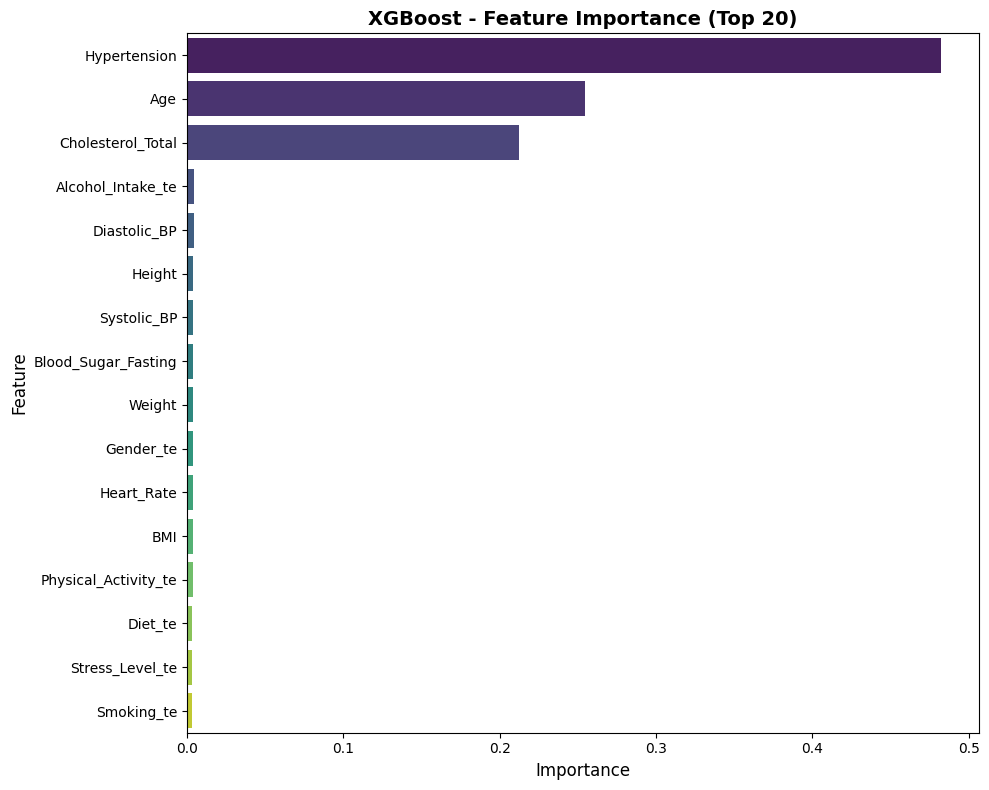

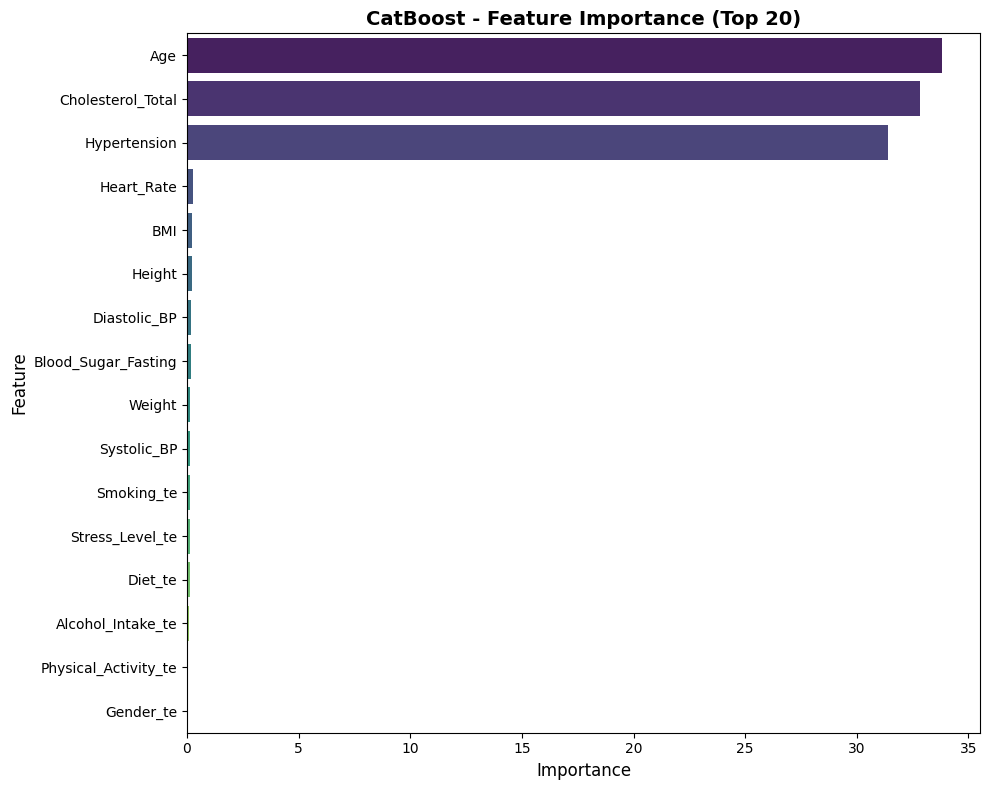


📊 XGBoost Top Features:
                 Feature  Importance
4           Hypertension    0.482281
0                    Age    0.254358
9      Cholesterol_Total    0.212349
12     Alcohol_Intake_te    0.004662
6           Diastolic_BP    0.004378
2                 Height    0.004182
5            Systolic_BP    0.004163
8    Blood_Sugar_Fasting    0.004122
1                 Weight    0.003948
10             Gender_te    0.003940
7             Heart_Rate    0.003936
3                    BMI    0.003932
13  Physical_Activity_te    0.003905
14               Diet_te    0.003520
15       Stress_Level_te    0.003359
11            Smoking_te    0.002964

📊 CatBoost Top Features:
                 Feature  Importance
0                    Age   33.825945
9      Cholesterol_Total   32.812603
4           Hypertension   31.408065
7             Heart_Rate    0.286600
3                    BMI    0.234041
2                 Height    0.206949
6           Diastolic_BP    0.186657
8    Blood_Sugar_Fasting

In [23]:
# =============================================================================
# FEATURE IMPORTANCE
# =============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_feature_importance(model, feature_names, model_name="Model", top_n=20):
    """
    Plot feature importance from tree-based models.
    """
    if hasattr(model, 'feature_importances_'):
        importance = model.feature_importances_
    else:
        print(f"⚠️ {model_name} doesn't have feature_importances_ attribute")
        return None
    
    # Create DataFrame
    feat_imp_df = (
        pd.DataFrame({'Feature': feature_names, 'Importance': importance})
        .sort_values('Importance', ascending=False)
        .head(top_n)
    )
    
    # Plot
    plt.figure(figsize=(10, 8))
    sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
    plt.title(f'{model_name} - Feature Importance (Top {top_n})', fontsize=14, fontweight='bold')
    plt.xlabel('Importance', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    return feat_imp_df


# Assuming these exist:
# num_cols = [...]
# cols_to_encode = [...]

all_encoded_cols = [f"{col}_te" for col in cols_to_encode]
feature_names = num_cols + all_encoded_cols

print("\n📊 FEATURE IMPORTANCE")
print("="*50)
xgb_importance = plot_feature_importance(final_xgb, feature_names, "XGBoost")
cat_importance = plot_feature_importance(final_cat, feature_names, "CatBoost")

if xgb_importance is not None:
    print("\n📊 XGBoost Top Features:")
    print(xgb_importance)

if cat_importance is not None:
    print("\n📊 CatBoost Top Features:")
    print(cat_importance)

# SHAP FEATURE IMPORTANCE


XGBoost — SHAP analysis

XGBoost | base_values shape/info: (5000,)

XGBoost — Top SHAP (top 20)
------------------------------------------------------------


,feature,mean|SHAP|
0,Cholesterol_Total,3.497175
1,Age,3.469784
2,Hypertension,0.662846
3,Diastolic_BP,0.181886
4,BMI,0.132197
5,Weight,0.127014
6,Systolic_BP,0.116307
7,Blood_Sugar_Fasting,0.112637
8,Alcohol_Intake_te,0.025970
9,Diet_te,0.017904


XGBoost | SHAP summary (dot)


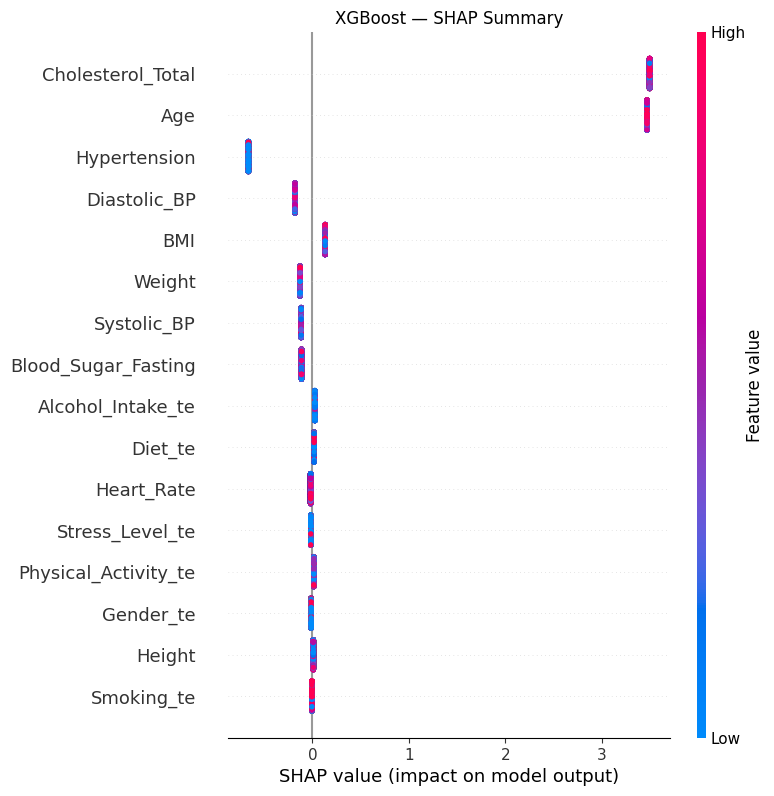

XGBoost | SHAP summary (bar)


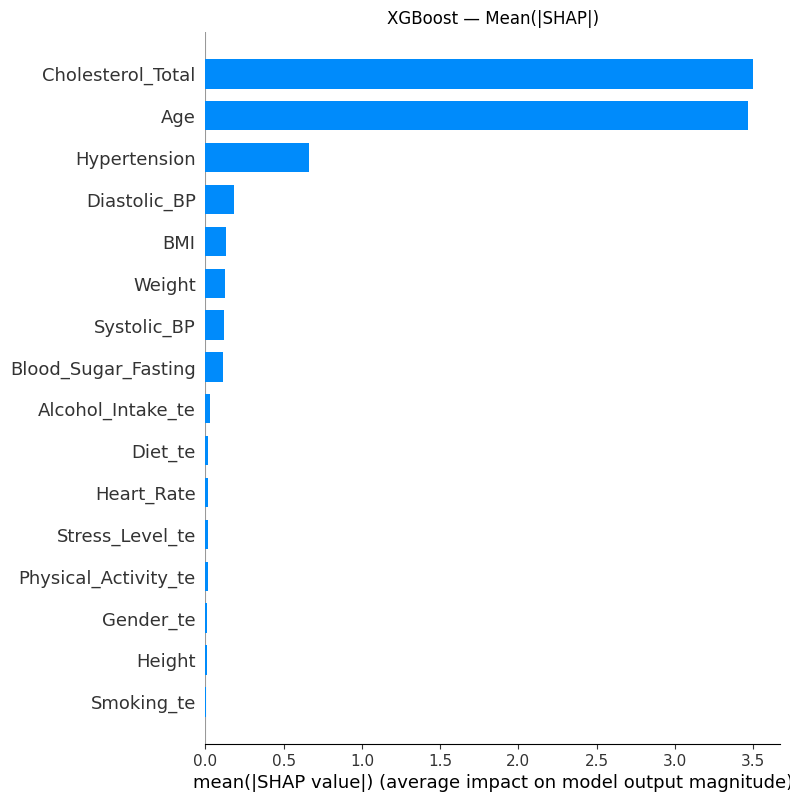


Top 30 (XGBoost):


,feature,mean|SHAP|
0,Cholesterol_Total,3.497175
1,Age,3.469784
2,Hypertension,0.662846
3,Diastolic_BP,0.181886
4,BMI,0.132197
5,Weight,0.127014
6,Systolic_BP,0.116307
7,Blood_Sugar_Fasting,0.112637
8,Alcohol_Intake_te,0.025970
9,Diet_te,0.017904



CatBoost — SHAP analysis

CatBoost | base_values shape/info: (5000,)

CatBoost — Top SHAP (top 20)
------------------------------------------------------------


,feature,mean|SHAP|
0,Cholesterol_Total,2.516789
1,Age,2.154494
2,Hypertension,1.137567
3,Heart_Rate,0.188644
4,Systolic_BP,0.106896
5,Diastolic_BP,0.049243
6,BMI,0.038543
7,Height,0.035291
8,Blood_Sugar_Fasting,0.034960
9,Smoking_te,0.020653


CatBoost | SHAP summary (dot)


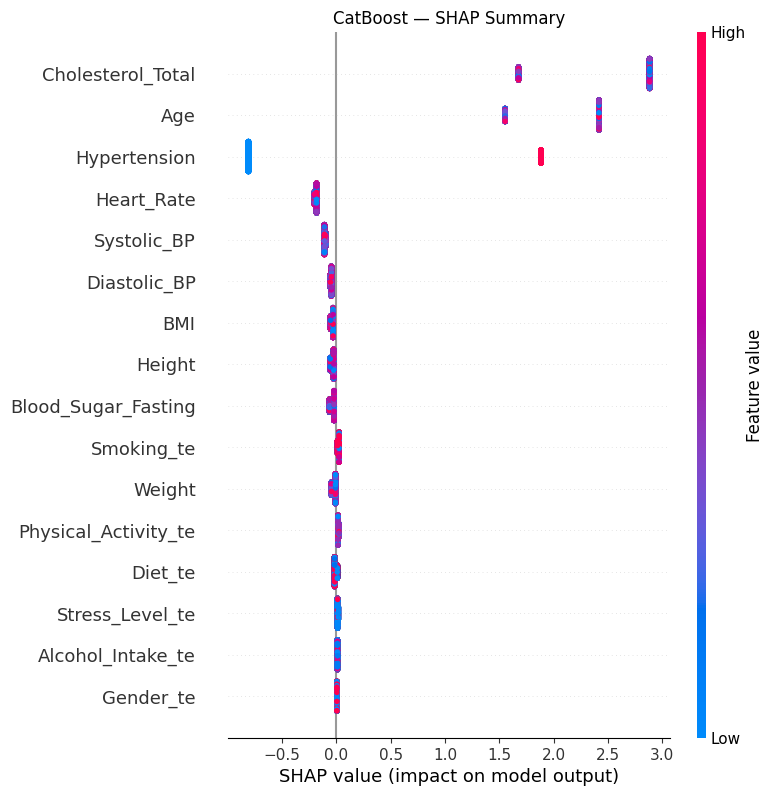

CatBoost | SHAP summary (bar)


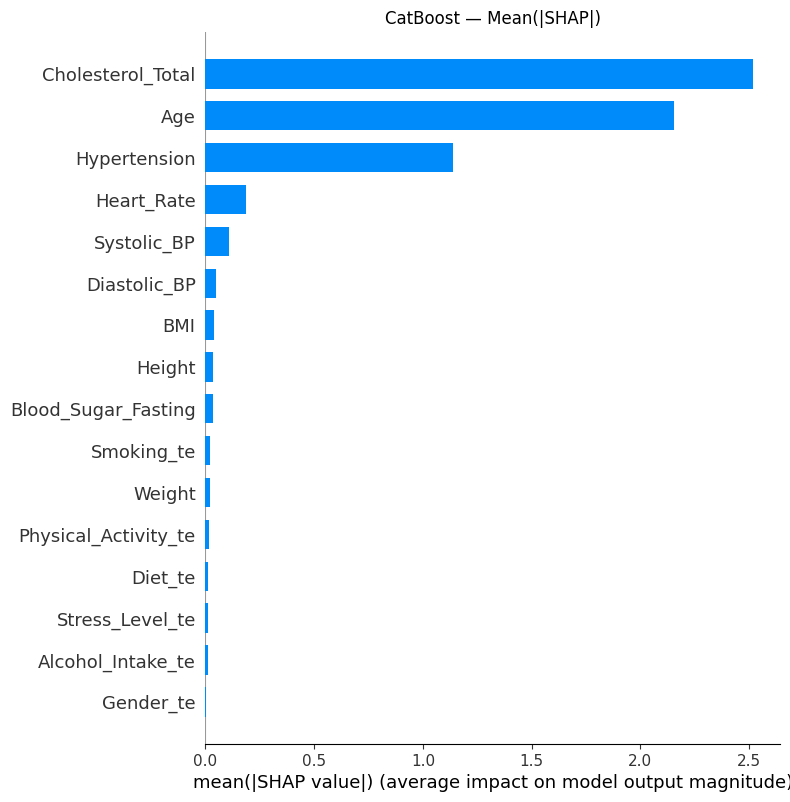


Top 30 (CatBoost):


,feature,mean|SHAP|
0,Cholesterol_Total,2.516789
1,Age,2.154494
2,Hypertension,1.137567
3,Heart_Rate,0.188644
4,Systolic_BP,0.106896
5,Diastolic_BP,0.049243
6,BMI,0.038543
7,Height,0.035291
8,Blood_Sugar_Fasting,0.034960
9,Smoking_te,0.020653


In [24]:
# ============================================================
# FULL SHAP PIPELINE (binary & multiclass) + GPU TargetEncoder
# ============================================================
import numpy as np
import pandas as pd
import torch
import shap
import matplotlib.pyplot as plt
from typing import Tuple
from sklearn.base import BaseEstimator, TransformerMixin
from IPython.display import display

# If you're in a notebook, init JS once (safe to call multiple times)
shap.initjs()

# --------------------------
# Robust GPU Target Encoder
# --------------------------
class TargetEncoder(BaseEstimator, TransformerMixin):
    """GPU-accelerated target encoder using PyTorch, robust to missing cols."""
    def __init__(self, columns, smoothing=10.0):
        self.columns = list(columns)
        self.smoothing = float(smoothing)
        self.mappings = {}
        self.global_mean = None
        self.device = "cuda" if torch.cuda.is_available() else "cpu"

    def fit(self, X, y):
        X = X.copy()
        y = pd.Series(y)
        self.global_mean = float(y.mean())

        for col in self.columns:
            if col not in X.columns:         # guard
                continue
            values, categories = pd.factorize(X[col], sort=True)

            idx_t = torch.tensor(values, dtype=torch.long, device=self.device)
            y_t   = torch.tensor(y.values, dtype=torch.float, device=self.device)

            n_cats = int(len(categories))
            counts = torch.zeros(n_cats, dtype=torch.float, device=self.device)
            sums   = torch.zeros(n_cats, dtype=torch.float, device=self.device)

            counts.scatter_add_(0, idx_t, torch.ones_like(y_t))
            sums.scatter_add_(0, idx_t, y_t)

            means    = sums / counts.clamp(min=1e-5)
            smoothed = (means * counts + self.global_mean * self.smoothing) / (counts + self.smoothing)

            self.mappings[col] = dict(zip(categories.tolist(), smoothed.detach().cpu().numpy()))
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            if col not in X.columns:         # guard
                continue
            mapping = self.mappings.get(col, {})
            X[f"{col}_te"] = X[col].map(mapping).fillna(self.global_mean)
        to_drop = [c for c in self.columns if c in X.columns]
        return X.drop(columns=to_drop)

# -------------------------------------
# Helpers: uniform DataFrame handling
# -------------------------------------
def _as_dataframe(data, feature_names=None):
    """Ensure we return a DataFrame with usable column names."""
    if isinstance(data, pd.DataFrame):
        return data
    arr = np.asarray(data)
    if feature_names is None:
        feature_names = [f"f{i}" for i in range(arr.shape[1])]
    return pd.DataFrame(arr, columns=feature_names)

def _names_from_transformer(transformer, fallback_n_cols=None):
    """Try to pull feature names from common encoders/scalers; else None/fallback."""
    # scikit-learn API (>=1.0)
    if hasattr(transformer, "get_feature_names_out"):
        try:
            return list(transformer.get_feature_names_out())
        except Exception:
            pass
    # category_encoders / custom encoders
    for attr in ("feature_names_", "cols", "columns"):
        if hasattr(transformer, attr):
            names = getattr(transformer, attr)
            if names is not None:
                try:
                    return list(names)
                except Exception:
                    pass
    if fallback_n_cols is not None:
        return [f"f{i}" for i in range(fallback_n_cols)]
    return None

def _transform_like_training(X_raw: pd.DataFrame, te, scaler) -> Tuple[pd.DataFrame, list]:
    """Apply the same te/scaler used in training, returning DataFrame + names."""
    X_work = X_raw.copy()

    # 1) Target / categorical encoding
    if te is not None and hasattr(te, "transform"):
        X_work_t = te.transform(X_work)
        feat_names_te = _names_from_transformer(te)
        X_work = X_work_t if isinstance(X_work_t, pd.DataFrame) else _as_dataframe(X_work_t, feat_names_te)

    # 2) Scaling
    if scaler is not None and hasattr(scaler, "transform"):
        if hasattr(scaler, "feature_names_in_"):
            # Align column order to training-time columns
            X_work = X_work.reindex(columns=scaler.feature_names_in_, fill_value=0)
        X_scaled = scaler.transform(X_work)


    return X_work, list(X_work.columns)

def _extract_shap_values(explainer, X_mat):
    """
    Return a unified dict:
      {"values": np.ndarray or list per class, "base_values": ..., "is_multiclass": bool}
    Works with both new (explainer(X)) and old (.shap_values) APIs.
    """
    try:
        sv = explainer(X_mat)  # new API
        vals = sv.values
        base = sv.base_values
        is_multi = isinstance(vals, np.ndarray) and vals.ndim == 3  # (n,f,C)
        return {"values": vals, "base_values": base, "is_multiclass": is_multi}
    except Exception:
        # old API fallback
        vals = explainer.shap_values(X_mat)
        base = getattr(explainer, "expected_value", None)
        if isinstance(vals, list):  # multiclass: list of (n,f) per class
            return {"values": vals, "base_values": base, "is_multiclass": True}
        else:
            return {"values": vals, "base_values": base, "is_multiclass": False}

def _print_top_importance(shap_array, feature_names, top_n=20, header="Top SHAP features"):
    """Print a ranked table of mean(|SHAP|) per feature."""
    mean_abs = np.abs(shap_array).mean(axis=0)
    order = np.argsort(-mean_abs)
    top_idx = order[:top_n]
    df_imp = pd.DataFrame({
        "feature": [feature_names[i] for i in top_idx],
        "mean|SHAP|": mean_abs[top_idx]
    })
    print(f"\n{header} (top {top_n})")
    print("-" * 60)
    display(df_imp)

def _summary_plots(shap_vals, X_df, feature_names, model_name="Model"):
    """
    Draw SHAP bar + dot summary.
    Handles:
      - Binary/regression: ndarray (n,f)
      - Multiclass: ndarray (n,f,C) or list of (n,f)
    """
    if isinstance(shap_vals, list):
        for c, arr in enumerate(shap_vals):
            _print_top_importance(arr, feature_names, header=f"{model_name} | Class {c} — Top SHAP")
            print(f"{model_name} | SHAP summary (dot) — Class {c}")
            shap.summary_plot(arr, X_df, show=False)
            plt.title(f"{model_name} — SHAP Summary (Class {c})")
            plt.show()

            print(f"{model_name} | SHAP summary (bar) — Class {c}")
            shap.summary_plot(arr, X_df, plot_type="bar", show=False)
            plt.title(f"{model_name} — Mean(|SHAP|) (Class {c})")
            plt.show()
    else:
        arr = np.asarray(shap_vals)
        if arr.ndim == 3:
            C = arr.shape[2]
            for c in range(C):
                arr_c = arr[:, :, c]
                _print_top_importance(arr_c, feature_names, header=f"{model_name} | Class {c} — Top SHAP")
                print(f"{model_name} | SHAP summary (dot) — Class {c}")
                shap.summary_plot(arr_c, X_df, show=False)
                plt.title(f"{model_name} — SHAP Summary (Class {c})")
                plt.show()

                print(f"{model_name} | SHAP summary (bar) — Class {c}")
                shap.summary_plot(arr_c, X_df, plot_type="bar", show=False)
                plt.title(f"{model_name} — Mean(|SHAP|) (Class {c})")
                plt.show()
        else:
            _print_top_importance(arr, feature_names, header=f"{model_name} — Top SHAP")
            print(f"{model_name} | SHAP summary (dot)")
            shap.summary_plot(arr, X_df, show=False)
            plt.title(f"{model_name} — SHAP Summary")
            plt.show()

            print(f"{model_name} | SHAP summary (bar)")
            shap.summary_plot(arr, X_df, plot_type="bar", show=False)
            plt.title(f"{model_name} — Mean(|SHAP|)")
            plt.show()

def shap_for_model(model, X_raw, te, scaler, model_name="Model", sample=5000):
    """
    Compute & plot SHAP for a trained model using the SAME preprocessing used in training.
    - X_raw: original (pre-encoding) DataFrame used in training
    - te/scaler: objects returned by your train_final_model (or None)
    """
    # Transform X the same way as training
    X_final, feat_names = _transform_like_training(X_raw, te, scaler)

    # Optional sampling for speed
    if sample and len(X_final) > sample:
        idx = np.random.RandomState(42).choice(len(X_final), size=sample, replace=False)
        X_final = X_final.iloc[idx].reset_index(drop=True)

    # Choose the best explainer for tree models
    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        explainer = shap.Explainer(model, X_final)

    sv = _extract_shap_values(explainer, X_final.values)

    # Base values info
    if isinstance(sv["base_values"], (list, np.ndarray)):
        print(f"\n{model_name} | base_values shape/info:", 
              np.array(sv["base_values"]).shape)
    else:
        print(f"\n{model_name} | base_value:", sv["base_values"])

    # Plots + top-k tables
    _summary_plots(sv["values"], X_final, feat_names, model_name=model_name)

    # ===== Build importance table =====
    vals = sv["values"]
    if isinstance(vals, list):
        # Multiclass (old API): list of (n,f) arrays
        per_class = []
        for c, arr in enumerate(vals):
            per_class.append(
                pd.DataFrame({
                    "feature": feat_names,
                    f"mean|SHAP|_class{c}": np.abs(arr).mean(axis=0)
                })
            )
        imp = per_class[0]
        for dfc in per_class[1:]:
            imp = imp.merge(dfc, on="feature", how="inner")
        imp["mean|SHAP|_overall"] = imp.filter(like="mean|SHAP|_class").mean(axis=1)
        imp = imp.sort_values("mean|SHAP|_overall", ascending=False).reset_index(drop=True)

    else:
        arr = np.asarray(vals)
        if arr.ndim == 3:
            # Multiclass (new API): (n, f, C)
            C = arr.shape[2]
            per_class = []
            for c in range(C):
                per_class.append(
                    pd.DataFrame({
                        "feature": feat_names,
                        f"mean|SHAP|_class{c}": np.abs(arr[:, :, c]).mean(axis=0)
                    })
                )
            imp = per_class[0]
            for dfc in per_class[1:]:
                imp = imp.merge(dfc, on="feature", how="inner")
            imp["mean|SHAP|_overall"] = imp.filter(like="mean|SHAP|_class").mean(axis=1)
            imp = imp.sort_values("mean|SHAP|_overall", ascending=False).reset_index(drop=True)
        else:
            # Binary / regression: (n, f)
            imp = pd.DataFrame({
                "feature": feat_names,
                "mean|SHAP|": np.abs(arr).mean(axis=0)
            }).sort_values("mean|SHAP|", ascending=False).reset_index(drop=True)

    # Final safety check + return
    assert isinstance(imp, pd.DataFrame) and len(imp) > 0, "Empty SHAP importance table"
    return imp

# ============================================================
# USAGE EXAMPLE (assumes you have final_xgb/final_cat + te/scalers)
# ============================================================

print("\n" + "="*70 + "\nXGBoost — SHAP analysis\n" + "="*70)
imp_xgb = shap_for_model(final_xgb, X_raw=X, te=te_xgb, scaler=scaler_xgb,
                         model_name="XGBoost", sample=5000)
print("\nTop 30 (XGBoost):")
display(imp_xgb.head(30))

print("\n" + "="*70 + "\nCatBoost — SHAP analysis\n" + "="*70)
imp_cat = shap_for_model(final_cat, X_raw=X, te=te_cat, scaler=scaler_cat,
                         model_name="CatBoost", sample=5000)
print("\nTop 30 (CatBoost):")
display(imp_cat.head(30))

In [25]:
# ============================================================
# PATCHED: collision-proof SHAP utilities + per-class analysis
# (feature name alignment fix + debug logging)
# ============================================================
import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt

# ============================================================
# Safe, unique helper names (avoid namespace collision)
# ============================================================
def __shap_as_df(data, feature_names=None):
    if isinstance(data, pd.DataFrame):
        return data
    arr = np.asarray(data)
    if feature_names is None:
        feature_names = [f"f{i}" for i in range(arr.shape[1])]
    return pd.DataFrame(arr, columns=feature_names)

def __shap_names_from_transformer(t, fallback_n_cols=None):
    # sklearn API
    if hasattr(t, "get_feature_names_out"):
        try:
            return list(t.get_feature_names_out())
        except Exception:
            pass
    # category_encoders / custom encoders
    for attr in ("feature_names_", "cols", "columns"):
        if hasattr(t, attr):
            try:
                val = getattr(t, attr)
                if val is not None:
                    return list(val)
            except Exception:
                pass
    if fallback_n_cols is not None:
        return [f"f{i}" for i in range(fallback_n_cols)]
    return None

# ============================================================
# Preprocessing helper (with feature name alignment)
# ============================================================
def __shap_apply_preproc(X_raw: pd.DataFrame, te, scaler, verbose=False):
    """
    Apply the same encoder/scaler used in training.
    - Handles None, single transformer, or sequence (list/tuple)
    - Ensures column alignment with training-time feature order
    - Returns: (X_final_df, feature_names)
    """
    Xw = X_raw.copy()

    def _apply_one(transformer, Xdf):
        if transformer is None or not hasattr(transformer, "transform"):
            return Xdf

        # 🔧 Align DataFrame columns to match what transformer was fitted on
        if hasattr(transformer, "feature_names_in_"):
            trained_cols = list(transformer.feature_names_in_)
            missing_cols = [c for c in trained_cols if c not in Xdf.columns]
            extra_cols = [c for c in Xdf.columns if c not in trained_cols]

            if verbose and (missing_cols or extra_cols):
                print(f"[DEBUG] Transformer: {transformer.__class__.__name__}")
                if missing_cols:
                    print(f"  Missing columns (filled with 0): {missing_cols}")
                if extra_cols:
                    print(f"  Extra columns ignored: {extra_cols}")

            # Align order + fill missing with 0
            Xdf = Xdf.reindex(columns=trained_cols, fill_value=0)

        Xt = transformer.transform(Xdf)
        names = __shap_names_from_transformer(transformer, fallback_n_cols=Xdf.shape[1])
        return __shap_as_df(Xt, names if names else list(Xdf.columns))

    # 1️⃣ Apply encoders
    if te is not None:
        if isinstance(te, (list, tuple)):
            for t in te:
                Xw = _apply_one(t, Xw)
        else:
            Xw = _apply_one(te, Xw)

    # 2️⃣ Apply scalers
    if scaler is not None:
        if isinstance(scaler, (list, tuple)):
            for s in scaler:
                Xw = _apply_one(s, Xw)
        else:
            Xw = _apply_one(scaler, Xw)

    return Xw, list(Xw.columns)

# ============================================================
# Helper: print top features
# ============================================================
def __shap_print_top(arr, feature_names, header, top_n=20):
    mean_abs = np.abs(arr).mean(axis=0)
    order = np.argsort(-mean_abs)[:top_n]
    df = pd.DataFrame({
        "feature": [feature_names[i] for i in order],
        "mean|SHAP|": mean_abs[order]
    })
    print("\n" + header)
    print("-" * 60)
    display(df)

# ============================================================
# Binary per-class SHAP plots (0 = -1 on log-odds scale)
# ============================================================
def __shap_per_class_binary_plots(arr_pos, X_df, feature_names, model_name="Model"):
    # Class 1 (positive)
    __shap_print_top(arr_pos, feature_names, f"{model_name} | Class 1 (positive) — Top SHAP")
    shap.summary_plot(arr_pos, X_df, show=False)
    plt.title(f"{model_name} — SHAP Summary (Class 1)")
    plt.show()

    shap.summary_plot(arr_pos, X_df, plot_type="bar", show=False)
    plt.title(f"{model_name} — Mean(|SHAP|) (Class 1)")
    plt.show()

    # Class 0 (negative)
    arr_neg = -arr_pos
    __shap_print_top(arr_neg, feature_names, f"{model_name} | Class 0 (negative) — Top SHAP")
    shap.summary_plot(arr_neg, X_df, show=False)
    plt.title(f"{model_name} — SHAP Summary (Class 0)")
    plt.show()

    shap.summary_plot(arr_neg, X_df, plot_type="bar", show=False)
    plt.title(f"{model_name} — Mean(|SHAP|) (Class 0)")
    plt.show()

# ============================================================
# Main function: SHAP per-class (handles binary, multiclass, regression)
# ============================================================
def shap_for_model_per_class(model, X_raw, te=None, scaler=None, model_name="Model", sample=5000, verbose=False):
    """
    Collision-proof SHAP pipeline with feature-name alignment.
    Works for tree & non-tree models; binary, multiclass, or regression.
    """
    # 🔹 Step 1: Rebuild preprocessed feature matrix
    X_final, feat_names = __shap_apply_preproc(X_raw, te, scaler, verbose=verbose)

    # 🔹 Step 2: Optional sampling for speed
    if sample and len(X_final) > sample:
        idx = np.random.RandomState(42).choice(len(X_final), size=sample, replace=False)
        X_final = X_final.iloc[idx].reset_index(drop=True)

    # 🔹 Step 3: Build SHAP explainer
    try:
        explainer = shap.TreeExplainer(model)
    except Exception:
        explainer = shap.Explainer(model, X_final)

    # 🔹 Step 4: Extract SHAP values
    try:
        sv = explainer(X_final.values)
        shap_vals = sv.values
        base_vals = sv.base_values
    except Exception:
        shap_vals = explainer.shap_values(X_final.values)
        base_vals = getattr(explainer, "expected_value", None)

    # =====================================================
    # Multiclass case (list of arrays or ndarray n×f×C)
    # =====================================================
    if isinstance(shap_vals, list):
        per_class = []
        for c, arr in enumerate(shap_vals):
            __shap_print_top(arr, feat_names, f"{model_name} | Class {c} — Top SHAP")
            shap.summary_plot(arr, X_final, show=False)
            plt.title(f"{model_name} — SHAP Summary (Class {c})")
            plt.show()

            shap.summary_plot(arr, X_final, plot_type="bar", show=False)
            plt.title(f"{model_name} — Mean(|SHAP|) (Class {c})")
            plt.show()

            per_class.append(pd.DataFrame({
                "feature": feat_names,
                f"mean|SHAP|_class{c}": np.abs(arr).mean(axis=0)
            }))
        imp = per_class[0]
        for dfc in per_class[1:]:
            imp = imp.merge(dfc, on="feature", how="inner")
        imp["mean|SHAP|_overall"] = imp.filter(like="mean|SHAP|_class").mean(axis=1)
        return imp.sort_values("mean|SHAP|_overall", ascending=False).reset_index(drop=True)

    arr = np.asarray(shap_vals)
    if arr.ndim == 3:  # (n,f,C)
        C = arr.shape[2]
        per_class = []
        for c in range(C):
            arr_c = arr[:, :, c]
            __shap_print_top(arr_c, feat_names, f"{model_name} | Class {c} — Top SHAP")
            shap.summary_plot(arr_c, X_final, show=False)
            plt.title(f"{model_name} — SHAP Summary (Class {c})")
            plt.show()

            shap.summary_plot(arr_c, X_final, plot_type="bar", show=False)
            plt.title(f"{model_name} — Mean(|SHAP|) (Class {c})")
            plt.show()

            per_class.append(pd.DataFrame({
                "feature": feat_names,
                f"mean|SHAP|_class{c}": np.abs(arr_c).mean(axis=0)
            }))
        imp = per_class[0]
        for dfc in per_class[1:]:
            imp = imp.merge(dfc, on="feature", how="inner")
        imp["mean|SHAP|_overall"] = imp.filter(like="mean|SHAP|_class").mean(axis=1)
        return imp.sort_values("mean|SHAP|_overall", ascending=False).reset_index(drop=True)

    # =====================================================
    # Binary classification
    # =====================================================
    if arr.ndim == 2 and hasattr(model, "classes_") and len(getattr(model, "classes_", [])) == 2:
        print(f"\n{model_name} — Binary classifier detected. Plotting Class 1 & Class 0 (=-Class 1).")
        __shap_per_class_binary_plots(arr, X_final, feat_names, model_name=model_name)
        df_imp = pd.DataFrame({
            "feature": feat_names,
            "mean|SHAP|_class1": np.abs(arr).mean(axis=0),
            "mean|SHAP|_class0": np.abs(-arr).mean(axis=0)
        })
        df_imp["mean|SHAP|_overall"] = df_imp[["mean|SHAP|_class0", "mean|SHAP|_class1"]].mean(axis=1)
        return df_imp.sort_values("mean|SHAP|_overall", ascending=False).reset_index(drop=True)

    # =====================================================
    # Regression / single-output models
    # =====================================================
    print(f"\n{model_name} — Single-output SHAP detected; using overall summary.")
    __shap_print_top(arr, feat_names, f"{model_name} — Top SHAP")
    shap.summary_plot(arr, X_final, show=False)
    plt.title(f"{model_name} — SHAP Summary")
    plt.show()

    shap.summary_plot(arr, X_final, plot_type="bar", show=False)
    plt.title(f"{model_name} — Mean(|SHAP|)")
    plt.show()

    return (pd.DataFrame({
        "feature": feat_names,
        "mean|SHAP|": np.abs(arr).mean(axis=0)
    }).sort_values("mean|SHAP|", ascending=False).reset_index(drop=True))



XGBoost — Per-Class SHAP
[DEBUG] Transformer: StandardScaler
  Extra columns ignored: ['Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']

XGBoost — Binary classifier detected. Plotting Class 1 & Class 0 (=-Class 1).

XGBoost | Class 1 (positive) — Top SHAP
------------------------------------------------------------


,feature,mean|SHAP|
0,Age,2.045335
1,Cholesterol_Total,1.804092
2,Hypertension,1.787231
3,Weight,0.035367
4,Heart_Rate,0.031987
5,BMI,0.031547
6,Blood_Sugar_Fasting,0.029470
7,Height,0.026724
8,Diastolic_BP,0.024623
9,Systolic_BP,0.020208


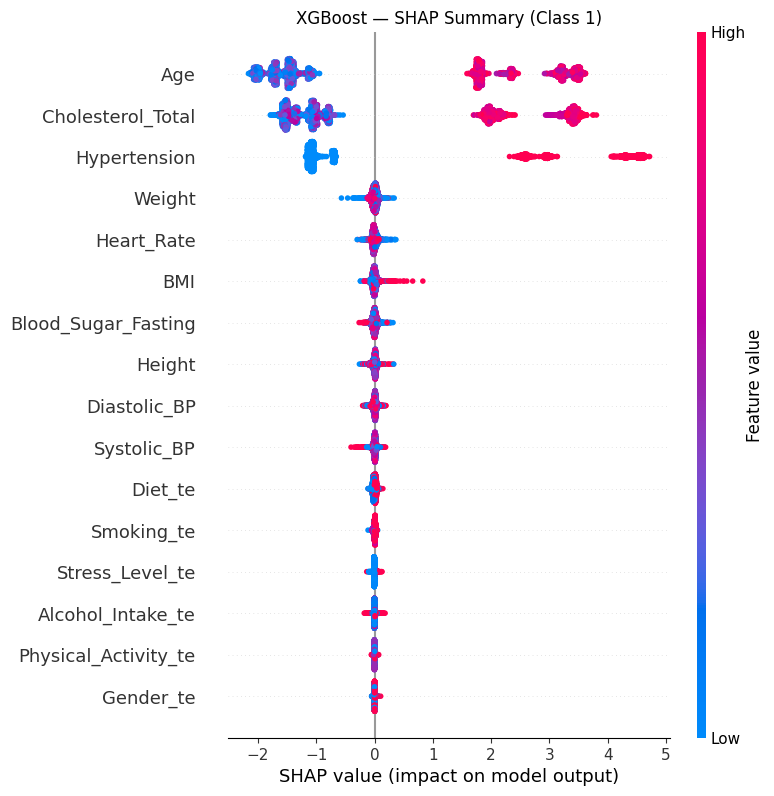

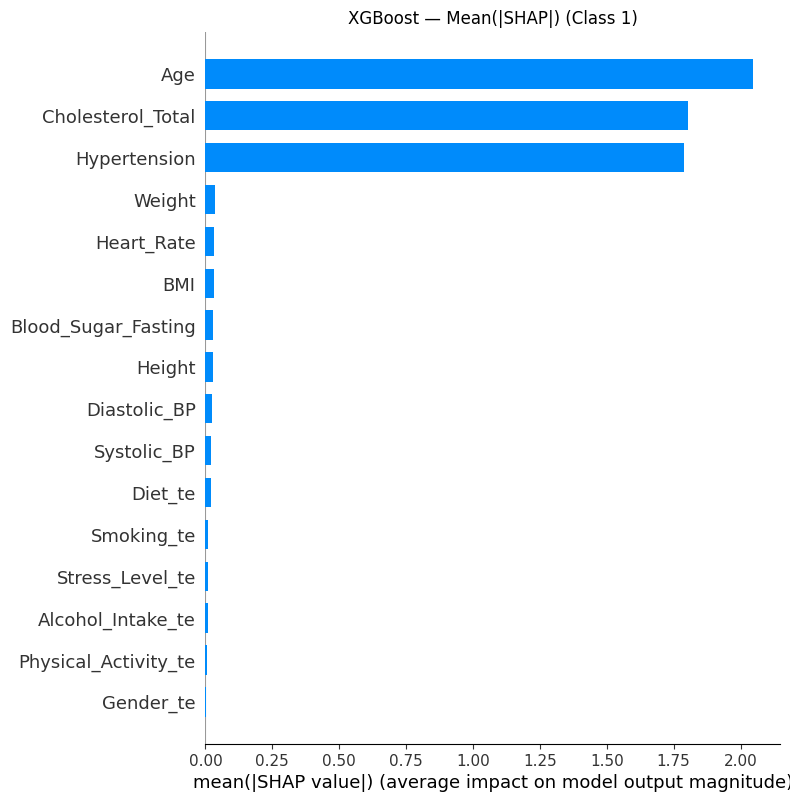


XGBoost | Class 0 (negative) — Top SHAP
------------------------------------------------------------


,feature,mean|SHAP|
0,Age,2.045335
1,Cholesterol_Total,1.804092
2,Hypertension,1.787231
3,Weight,0.035367
4,Heart_Rate,0.031987
5,BMI,0.031547
6,Blood_Sugar_Fasting,0.029470
7,Height,0.026724
8,Diastolic_BP,0.024623
9,Systolic_BP,0.020208


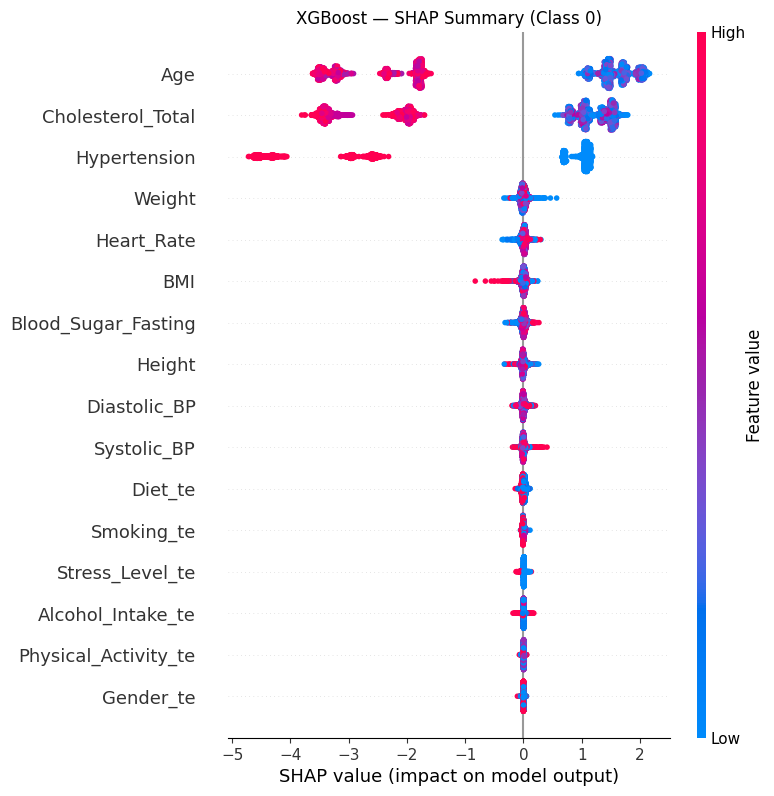

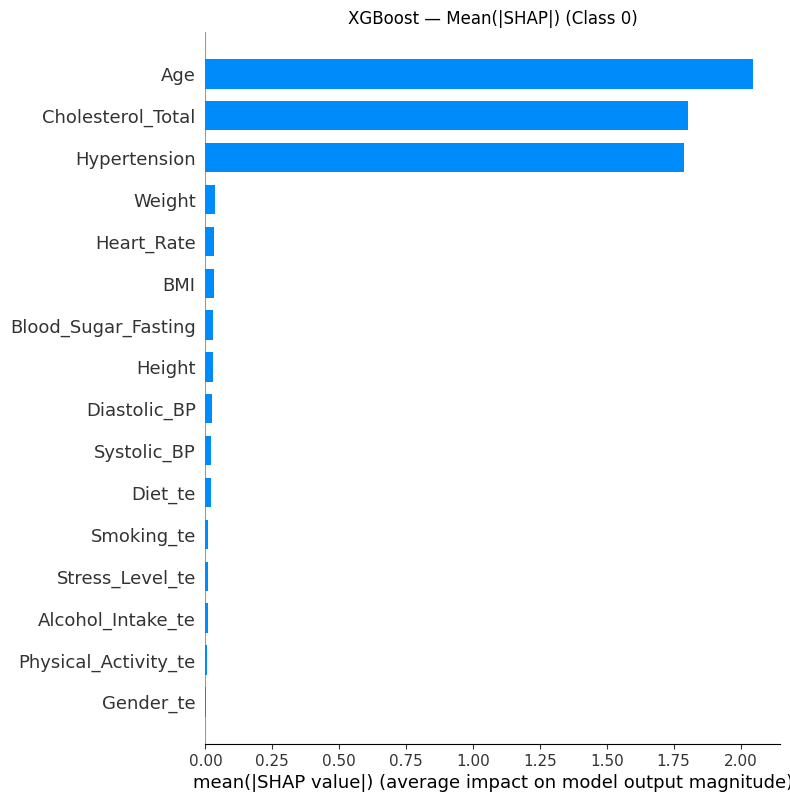


CatBoost — Per-Class SHAP
[DEBUG] Transformer: StandardScaler
  Extra columns ignored: ['Diabetes', 'Hyperlipidemia', 'Family_History', 'Previous_Heart_Attack']

CatBoost — Binary classifier detected. Plotting Class 1 & Class 0 (=-Class 1).

CatBoost | Class 1 (positive) — Top SHAP
------------------------------------------------------------


,feature,mean|SHAP|
0,Age,1.946985
1,Cholesterol_Total,1.872607
2,Hypertension,1.671446
3,Diet_te,0.019592
4,Heart_Rate,0.018726
5,Weight,0.015126
6,BMI,0.014700
7,Diastolic_BP,0.013373
8,Smoking_te,0.012140
9,Height,0.010167


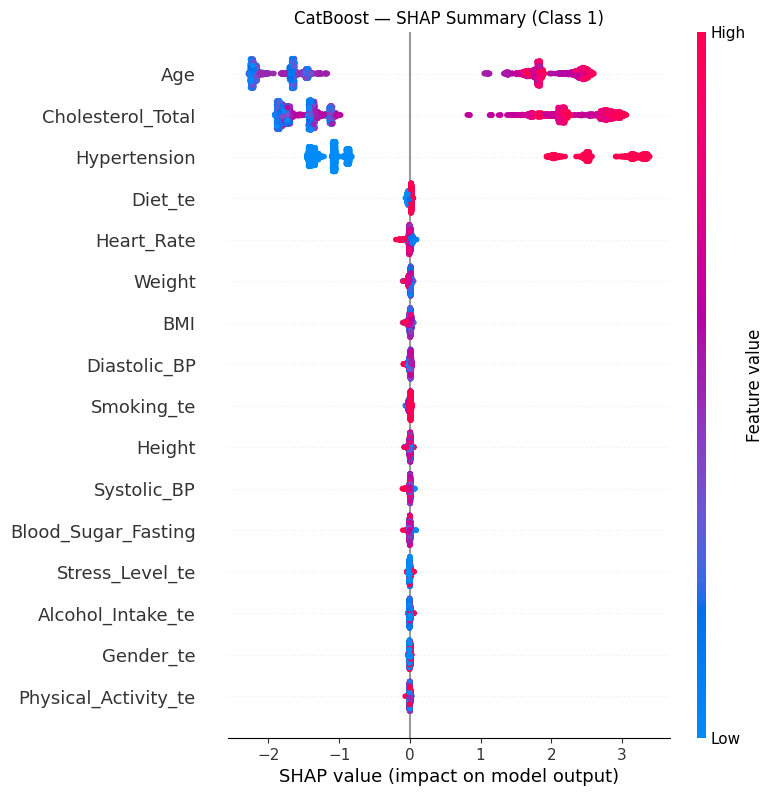

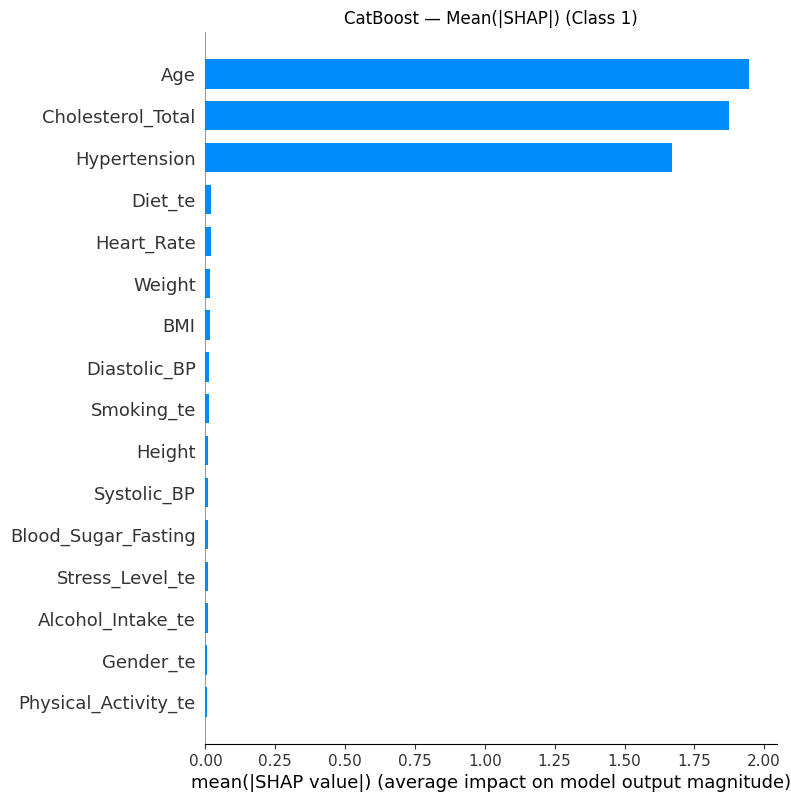


CatBoost | Class 0 (negative) — Top SHAP
------------------------------------------------------------


,feature,mean|SHAP|
0,Age,1.946985
1,Cholesterol_Total,1.872607
2,Hypertension,1.671446
3,Diet_te,0.019592
4,Heart_Rate,0.018726
5,Weight,0.015126
6,BMI,0.014700
7,Diastolic_BP,0.013373
8,Smoking_te,0.012140
9,Height,0.010167


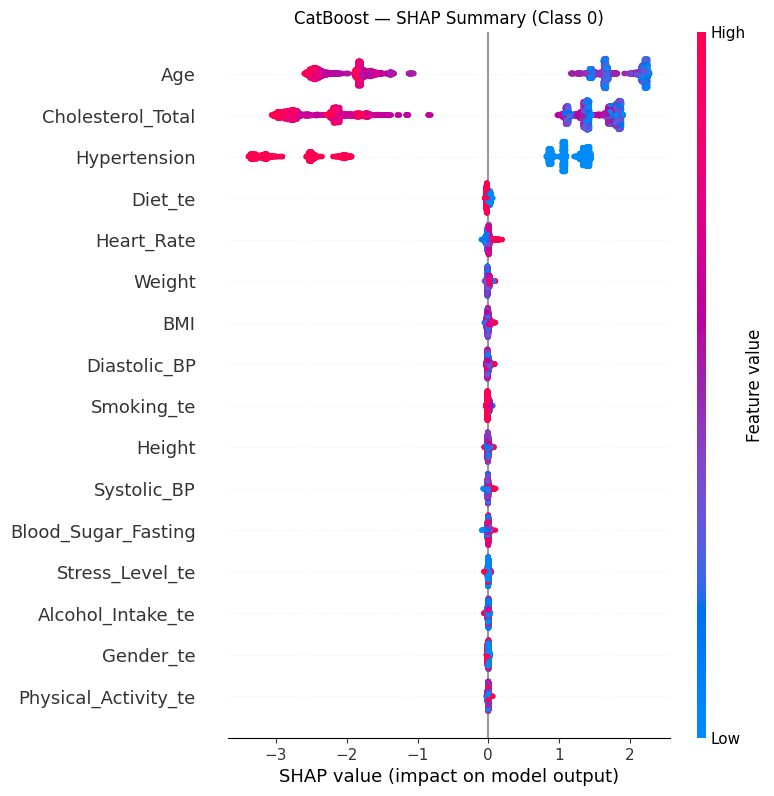

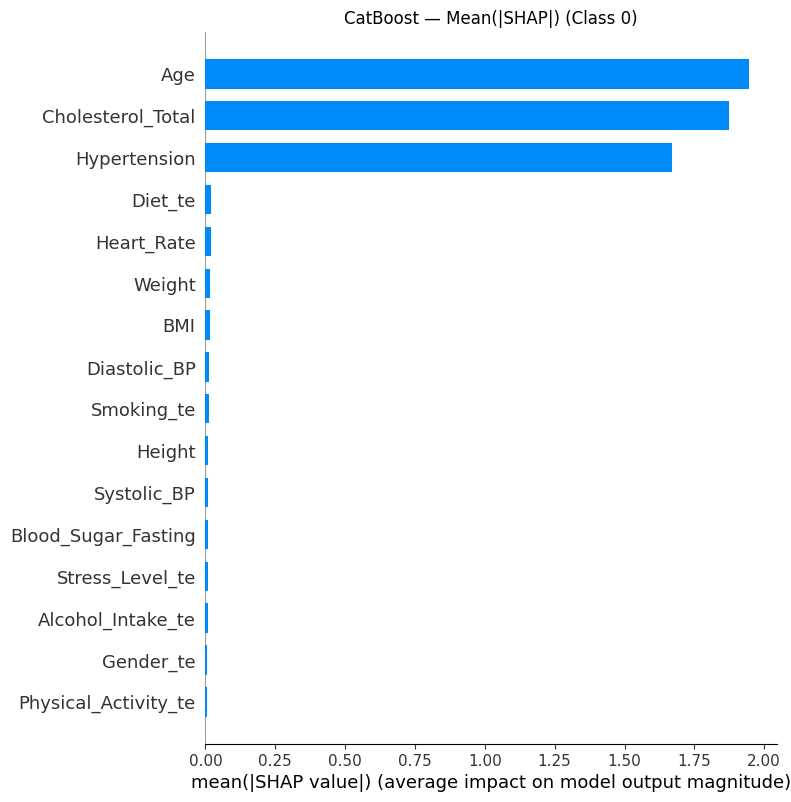

In [26]:
print("\n" + "="*70 + "\nXGBoost — Per-Class SHAP\n" + "="*70)
imp_xgb_perclass = shap_for_model_per_class(
    final_xgb, 
    X, 
    te_xgb, 
    scaler_xgb, 
    model_name="XGBoost", 
    sample=5000,
    verbose=True   # <- shows any missing/extra columns during preprocessing
)

print("\n" + "="*70 + "\nCatBoost — Per-Class SHAP\n" + "="*70)
imp_cat_perclass = shap_for_model_per_class(
    final_cat, 
    X, 
    te_cat, 
    scaler_cat, 
    model_name="CatBoost", 
    sample=5000,
    verbose=True
)


# Please Upvote If You Like It
# Thanks